##  Teknoloji ve Donanım (Spec) Skoru Hesaplama Kriterleri

Bu proje kapsamında oluşturulacak **"Teknoloji Skoru"**, ürünlerin yalnızca yazılımsal/elektronik yeniliklerini değil, aynı zamanda kapasite ve donanım güçlerini de kapsayan bir **"Genel Donanım ve Yetkinlik"** metriğidir. Adil bir karşılaştırma yapabilmek adına aşağıdaki kısıtlar ve kurallar dizisine bağlı kalınacaktır:

### 1. Alt Kategori (Subcategory) İzolasyonu
Ürünler arası elma-armut karşılaştırması yapmamak adına, her bir teknoloji skoru ve fiyat normalizasyonu **yalnızca ilgili alt kategori (örn: Sadece Buzdolapları, Sadece Çamaşır Makineleri) kendi içinde izole edilerek** hesaplanacaktır.

### 2. Değişken (Feature) Sınıflandırması ve Puanlama Kuralları
Ham veri setindeki özellikler 4 ana tipe ayrılacak ve aşağıdaki mantıkla sayısallaştırılacaktır:

*   **🟢 Tip A: İkili (Binary) Teknolojik Özellikler (Var/Yok)**
    *   *Tanım:* Ürüne doğrudan donanımsal artı katan spesifik özellikler (Örn: `Wi-Fi`, `Child_Lock`, `EverFresh_Technology`).
    *   *Kural:* Özellik hücrede mevcutsa `1`, boşsa (NaN) `0` puan verilir.
*   **🔵 Tip B: Sıralı (Ordinal) Kategorik Özellikler**
    *   *Tanım:* Hiyerarşi barındıran özellikler (Örn: `Energy_Class` -> A, B, C, D).
    *   *Kural:* En yüksek/verimli seviyeye en yüksek tam sayı puanı verilecek şekilde manuel ağırlıklandırma (Mapping) yapılır (Örn: A=5, B=4, C=3...).
*   **🟠 Tip C: Performans ve Kapasite Belirten Sayısal (Numeric) Özellikler**
    *   *Tanım:* Motor gücü, hacim, devir hızı gibi inovasyon olmasa da segmenti belirleyen sınırlar (Örn: `Motor_Gücü`, `Capacity`).
    *   *Kural:* Bu değerlerin diğer küçük puanları ezip geçmemesi için her bir sayısal kolon kendi içinde Min-Max Scaling yöntemiyle $0-100$ aralığına sıkıştırılır.
*   **🔴 Tip D: Tasarım, Fiziksel ve Tanımlayıcı Özellikler (Dışlananlar)**
    *   *Tanım:* Ürünün rengi, salt boyutsal ölçüleri ve ID'leri (Örn: `Color_Black`, `Height`, `Product_Link`).
    *   *Kural:* Teknoloji/Donanım skoruna hiçbir etkisi olmadığı için analizden **tamamen düşürülür (Drop)**.

### 3. Nihai Skoru Oluşturma ve Normalizasyon
*   Bir ürünün aldığı tüm A, B ve C tipi puanlar toplanarak "Ham Teknoloji Skoru" elde edilir.
*   Daha sonra bu ham skorlar, kategorinin en dolu ürünü $100$, en boş ürünü $0$ puan alacak şekilde aşağıdaki formülle normalize edilir:
    
$$Skor_{norm} = \frac{Skor - Skor_{min}}{Skor_{max} - Skor_{min}} \times 100$$

### 4. Segmentasyon ve Matris Hedefi
Elde edilen $0-100$ arası Teknoloji Skoru, yine $0-100$ arasına normalize edilmiş Fiyat Skoru ile 2 boyutlu bir düzlemde kıyaslanır. Hedefimiz 4 ana segmenti belirlemektir:
1.  **Premium / Amiral Gemileri:** Yüksek Teknoloji, Yüksek Fiyat
2.  **Giriş Seviyesi / Ekonomik:** Düşük Teknoloji, Düşük Fiyat
3.  **Tehlikeli Bölge (Overpriced):** Düşük Teknoloji, Yüksek Fiyat
4.  **Gizli Kahramanlar (Market Opportunity):** Yüksek Teknoloji, Düşük/Orta Fiyat *(Ana Odak)*

# Kütüphaneler

In [ ]:
import numpy as np
import pandas as pd 
import os
import re
import ast
from collections import Counter
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns   
from sklearn.cluster import KMeans
from collections import defaultdict
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import iplot
from sklearn.cluster import AgglomerativeClustering
import warnings
warnings.filterwarnings('ignore')

# İlk Bakış

In [ ]:
df = pd.read_csv(r"../web-scraping-data/data/claned/beko_claned.csv")
df_beko = df.copy()
df_beko.head()

In [ ]:
df_beko.shape

In [ ]:
df_beko.info(verbose = True, show_counts = True)

# Veri İşleme

In [ ]:
non_numeric_cols = df_beko.select_dtypes(exclude=[np.number]).columns

print("int/float olmayan sütun sayısı:", len(non_numeric_cols))
print("Sütunlar:")
print(list(non_numeric_cols))

In [ ]:
df_beko["Subcategory"].value_counts()

Subcategory değeri "Diğer" olan ürünler tespit edildi.


In [ ]:
# Sadece Subcategory'si 'Diğer' olanları filtrele
diger_df = df_beko[df_beko['Subcategory'] == 'Diğer']

# Bunların Ana Kategori ve Ürün Grubu dağılımına bakalım
print("--- 'Diğer' Kategorisindeki Ürünlerin Dağılımı ---")
print(diger_df[['Main_Category', 'Product_Group']].value_counts(dropna=False))

In [ ]:
# Senin belirlediğin kırılımlara göre Subcategory eşleştirme sözlüğü
category_mapping = {
    # --- Ankastre Ocaklar ---
    "Gazli Cam Tablali Ocak": "Ankastre Ocaklar",
    "Gazli Inoks Metal Tablali Ocaklar": "Ankastre Ocaklar",
    "Gazli Renkli Metal Tablali Ocaklar": "Ankastre Ocaklar",
    "Induksiyonlu Ocaklar": "Ankastre Ocaklar",
    "Vitroseramik Ocaklar": "Ankastre Ocaklar",
    "Domino Ocaklar": "Ankastre Ocaklar",
    "Entegre Davlumbazli Ocaklar": "Ankastre Ocaklar",

    # --- Ankastre Davlumbaz & Aspiratör ---
    "Ankastre Duvar Tipi Davlumbazlar": "Ankastre Davlumbazlar",
    "Ankastre Surgulu Aspirator": "Ankastre Aspiratörler",
    "Ankastre Mikrodalgalar": "Ankastre Mikrodalgalar",

    # --- Güzellik ve Kişisel Bakım ---
    "Cilt Bakim": "Güzellik ve Bakım",
    "Yaslanma Karsiti Bakim": "Güzellik ve Bakım",
    "Ozel Bakimlar": "Güzellik ve Bakım",
    "Sac Sakal Kesme Makineleri": "Kişisel Bakım",
    "Tiras Makineleri": "Kişisel Bakım",

    # --- Kahve ve Pişirici ---
    "Kahve Demleme Ekipmanlari": "Kahve Makinesi",
    "Kahve Ogutucu": "Kahve Makinesi",
    "Akilli Mutfak Robotu": "Pişirici",

    # --- Ev Temizlik & Süpürge & Ütü ---
    "Hali Ve Koltuk Yikama Makineleri": "Ev Temizlik Ekipmanları Teknolojisi",
    "Cam Temizleme Makineleri Ve Robotlari": "Ev Temizlik Ekipmanları Teknolojisi",
    "Buharli Temizleyiciler": "Ev Temizlik Ekipmanları Teknolojisi",
    "El Supurgesi": "Elektrikli Süpürge",
    "Toz Torbasi": "Elektrikli Süpürge",
    "Buharli Kirisik Giderici": "Ütü",
    "Seyahat Utusu": "Ütü",

    # --- Klima ---
    "Salon Tipi Klimalar": "Klima",

    # --- Elektronik, Aksesuar ve Giyilebilir ---
    "Sarj Cihazlari": "Cep Telefonu Aksesuarları",
    "Diger Telefon Aksesuarlari": "Cep Telefonu Aksesuarları",
    "Saat Ve Bileklik Aksesuari": "Giyilebilir Teknoloji",
    "Aksesuarlar": "Aksesuarlar",
    "Oyuncu Ekipmanlari": "Hobi Oyun Gaming Ürünleri",
    "Mouse": "Bilgisayar",
    "Cevre Birimleri": "Bilgisayar",
    "Ev Ici Akilli Kamera Sistemleri": "Ses ve Görüntü Sistemleri"
}

# "Diğer" olan satırları bul ve Product_Group değerine göre sözlükten yeni değerlerini at
mask = df_beko['Subcategory'] == 'Diğer'

# apply ve lambda kullanarak sözlükte karşılığı varsa yeni değeri, yoksa eski değerini (Diğer) bırakıyoruz
df_beko.loc[mask, 'Subcategory'] = df_beko.loc[mask, 'Product_Group'].apply(lambda x: category_mapping.get(x, 'Diğer'))

# İşlemin başarılı olup olmadığını kontrol edelim:
print("Kalan 'Diğer' sayısı:", len(df_beko[df_beko['Subcategory'] == 'Diğer']))

Subcategory değeri eksik olan satırlar Main_Category değerlerine göre dolduruldu.

In [ ]:
# Senin belirlediğin kırılımlara göre Main_Category eşleştirme sözlüğü
main_category_mapping = {
    # --- Ankastre ---
    "Gazli Cam Tablali Ocak": "Ankastre",
    "Gazli Inoks Metal Tablali Ocaklar": "Ankastre",
    "Gazli Renkli Metal Tablali Ocaklar": "Ankastre",
    "Induksiyonlu Ocaklar": "Ankastre",
    "Vitroseramik Ocaklar": "Ankastre",
    "Domino Ocaklar": "Ankastre",
    "Entegre Davlumbazli Ocaklar": "Ankastre",
    "Ankastre Duvar Tipi Davlumbazlar": "Ankastre",
    "Ankastre Surgulu Aspirator": "Ankastre",
    "Ankastre Mikrodalgalar": "Ankastre",

    # --- Küçük Ev Aletleri ---
    "Cilt Bakim": "Küçük Ev Aletleri",
    "Yaslanma Karsiti Bakim": "Küçük Ev Aletleri",
    "Ozel Bakimlar": "Küçük Ev Aletleri",
    "Sac Sakal Kesme Makineleri": "Küçük Ev Aletleri",
    "Tiras Makineleri": "Küçük Ev Aletleri",
    "Kahve Demleme Ekipmanlari": "Küçük Ev Aletleri",
    "Kahve Ogutucu": "Küçük Ev Aletleri",
    "Akilli Mutfak Robotu": "Küçük Ev Aletleri",
    "Hali Ve Koltuk Yikama Makineleri": "Küçük Ev Aletleri",
    "Cam Temizleme Makineleri Ve Robotlari": "Küçük Ev Aletleri",
    "Buharli Temizleyiciler": "Küçük Ev Aletleri",
    "El Supurgesi": "Küçük Ev Aletleri",
    "Toz Torbasi": "Küçük Ev Aletleri",
    "Buharli Kirisik Giderici": "Küçük Ev Aletleri",
    "Seyahat Utusu": "Küçük Ev Aletleri",

    # --- Isıtma Soğutma ve Enerji ---
    "Salon Tipi Klimalar": "Isıtma Soğutma ve Enerji",

    # --- Elektronik ---
    "Sarj Cihazlari": "Elektronik",
    "Diger Telefon Aksesuarlari": "Elektronik",
    "Saat Ve Bileklik Aksesuari": "Elektronik",
    "Oyuncu Ekipmanlari": "Elektronik",
    "Mouse": "Elektronik",
    "Cevre Birimleri": "Elektronik",
    "Ev Ici Akilli Kamera Sistemleri": "Elektronik",
    
    # --- Aksesuarlar ---
    "Aksesuarlar": "Aksesuarlar"
}

# Döngü ile Product_Group değerine bakıp Main_Category'yi güncelliyoruz
for prod_group, main_cat in main_category_mapping.items():
    df_beko.loc[df_beko['Product_Group'] == prod_group, 'Main_Category'] = main_cat

print("Main_Category güncellemesi tamamlandı!")

In [ ]:
# 1. Analize GİRMEYECEK (Gereksiz/Tanımlayıcı) sütunların bir listesini yapıyoruz
gereksiz_kolonlar = ['Product_Link', 'Product_Name', 'Main_Category', 'Product_Group', 'Product_Series']

# 2. Sayısal olmayan kolonları seç, ama "gereksiz_kolonlar" listesindekileri alma!
tum_kategorikler = df_beko.select_dtypes(exclude=[np.number]).columns
non_numeric_cols = [col for col in tum_kategorikler if col not in gereksiz_kolonlar]

# 3. Tüm sonuçları toplayacağımız boş liste
summary_data = []

# 4. Her bir Subcategory için döngü
for subcat in df_beko['Subcategory'].dropna().unique():
    df_sub = df_beko[df_beko['Subcategory'] == subcat]
    
    for col in non_numeric_cols:
        # Sütun tamamen boşsa atla
        if df_sub[col].isna().all():
            continue
            
        # Value counts hesapla
        vc = df_sub[col].value_counts(dropna=False).reset_index()
        vc.columns = ['Ozellik_Degeri', 'Frekans']
        
        vc.insert(0, 'Alt_Kategori', subcat)
        vc.insert(1, 'Kolon_Adi', col)
        
        summary_data.append(vc)

# 5. Listeyi DataFrame'e çevir
df_value_counts_summary = pd.concat(summary_data, ignore_index=True)

# 6. Kaydedilecek dosya yolu
dosya_yolu = r"..\web-scraping-data\data\claned\beko_non_numeric_columns.csv"

# BİLGİSAYARDAKİ TAM YOLU (ABSOLUTE PATH) BULUYORUZ
tam_yol = os.path.abspath(dosya_yolu)

# Dosyanın kaydedileceği klasör yapısı yoksa oluştur
os.makedirs(os.path.dirname(tam_yol), exist_ok=True)

# Sonucu TAM YOLA kaydet
df_value_counts_summary.to_csv(tam_yol, index=False, sep=';', encoding='utf-8-sig')

print("İşlem Tamamlandı!")
print(f"Lütfen şu adrese gidip dosyanı kontrol et:\n{tam_yol}")

In [ ]:
df_non_num = pd.read_csv(r"..\web-scraping-data\data\claned\beko_non_numeric_columns.csv", sep=';')

pd.set_option('display.max_rows', None)

display(df_non_num)

In [ ]:
len(df_non_num["Kolon_Adi"].value_counts())

In [ ]:
# 2. PANDAS SATIR LİMİTİNİ KALDIR (Hiçbir şeyi gizleme)
pd.set_option('display.max_rows', None)

# 3. Tabloyu mükemmel bir şekilde sırala (Böylece aynı kolonlar ve kategoriler alt alta dizilir)
df_sirali = df_non_num.sort_values(
    by=['Kolon_Adi', 'Alt_Kategori', 'Frekans'], 
    ascending=[True, True, False]
)

# 4. Sol baştaki eski karışık indeks numaralarını temizle (0,1,2.. diye düzgün başlasın)
df_sirali = df_sirali.reset_index(drop=True)

# 5. Düzgün zebra desenli tabloyu göster! (set_index kullanmıyoruz)
display(df_sirali)

# İnceleme bitince limiti eski haline döndürmek istersen:
# pd.reset_option('display.max_rows')

Kategorik verilerin skor işleminde nasıl işleneceği belirlendi.

In [ ]:
df_beko["Subcategory"].value_counts()

In [ ]:
# 1. SİLİNECEK KATEGORİLER
silinecek_kategoriler = [
    'Cep Telefonu', 'Ses& Görüntü Sistemleri', 'Ses ve Görüntü Sistemleri',
    'Giyilebilir Teknoloji', 'Bilgisayar', 'Cep Telefonu Aksesuarları',
    'Hobi - Oyun (Gaming) Ürünleri', 'Hobi Oyun Gaming Ürünleri', 
    'Outdoor Ekipman', 'Aksesuarlar'
]

# 2. SATIRLARI SİL: Hedef dışı kategorileri atıp doğrudan df_beko üzerine yazıyoruz
df_beko = df_beko[~df_beko['Subcategory'].isin(silinecek_kategoriler)]

# 3. BOŞ SÜTUNLARI SİL: Satırları silince tamamen (all) NaN kalan sütunları çöpe atıyoruz
df_beko = df_beko.dropna(axis=1, how='all')

# Temiz bir görünüm için indeksi sıfırlıyoruz
df_beko = df_beko.reset_index(drop=True)

In [ ]:
df_beko.shape

In [ ]:
# 1. Her iki sütunda da aynı anda veri bulunan satırları tespit et
ikisi_de_dolu = df_beko[df_beko['Energy_Class'].notnull() & df_beko['Energy_Class_Heating'].notnull()]

# 2. Sayıyı ve çakışan satırların değerlerini ekrana yazdır
print(f"Her iki sütunda da değer olan satır sayısı: {len(ikisi_de_dolu)}\n")

if len(ikisi_de_dolu) > 0:
    print("Çakışan Satırların Değerleri (Burada Energy_Class değerleri korunacaktır):")
    print(ikisi_de_dolu[['Energy_Class', 'Energy_Class_Heating']])

# 3. Sütunları eşle: Çakışmalarda Energy_Class kalsın, SADECE boş olanlar Energy_Class_Heating ile doldurulsun
df_beko['Energy_Class'] = df_beko['Energy_Class'].fillna(df_beko['Energy_Class_Heating'])

# 4. İşlevi biten Energy_Class_Heating sütununu çöpe at (kalıcı olarak df_beko'dan sil)
df_beko.drop(columns=['Energy_Class_Heating'], inplace=True)

# 5. İşlemin başarıyla gerçekleştiğini kontrol etmek için boş değer sayısına bakalım (İsteğe bağlı)
print(f"\nİşlem sonrası Energy_Class sütunundaki kalan boş değer sayısı: {df_beko['Energy_Class'].isnull().sum()}")

In [ ]:
# 1. Değer varsa 1, yoksa 0 yapılacak standart sütunların listesi
kategorik_sutunlar = [
    'Auto_Shut_off', 
    'Basket', 
    'Battery_Type', 
    'Bluetooth',
    'Cable_Winder', 
    'Caring_Coating', 
    'Parquet_/_Carpet_Brush',
    'Practical_Filter', 
    'Smart_Humidity_Sensor', 
    'Steam'
]

# Belirtilen sütunlarda değer varsa (not null) 1, yoksa (null) 0 yazdır
for sutun in kategorik_sutunlar:
    if sutun in df_beko.columns: # Sütun veri setinde var mı diye garanti altına alalım
        df_beko[sutun] = df_beko[sutun].notna().astype(int)

# 2. Steam_Cooking ve Steam_Assisted_Cooking sütunlarını birleştirme
# İki sütundan HERHANGİ BİRİNDE değer varsa (VEYA mantığı '|') 1, ikisi de boşsa 0 olacak
if 'Steam_Cooking' in df_beko.columns and 'Steam_Assisted_Cooking' in df_beko.columns:
    df_beko['Steam_Cooking_Combined'] = (
        df_beko['Steam_Cooking'].notna() | df_beko['Steam_Assisted_Cooking'].notna()
    ).astype(int)
    
    # İşlevi biten ve artık birleştirilmiş olan o iki eski sütunu kalıcı olarak çöpe at
    df_beko.drop(columns=['Steam_Cooking', 'Steam_Assisted_Cooking'], inplace=True)

# 3. Kontrol amaçlı: İşlem yapılan birkaç sütunun ilk 5 satırına ve genel değer dağılımlarına bakalım
print(df_beko[['Auto_Shut_off', 'Steam_Cooking_Combined']].head())

In [ ]:
# 1. YARDIMCI FONKSİYONLAR: Regex ile verinin içinden sayıları sağ salim çıkarma
def extract_number(val):
    """Metnin içindeki ilk sayıyı bulur (Birimleri ve yazıları yok sayar, 20.16 gibi ondalıkları yuvarlar)"""
    if pd.isna(val): return np.nan
    match = re.search(r'-?\d+\.?\d*', str(val).replace(',', '.'))
    if match: 
        return round(float(match.group()))
    return np.nan

def extract_min(val):
    """Aralık veya çoklu sayı barındıran metinden en küçük sayıyı (- değerlere dikkat ederek) çeker"""
    if pd.isna(val): return np.nan
    nums = [float(x) for x in re.findall(r'-?\d+\.?\d*', str(val).replace(',', '.'))]
    return round(min(nums)) if nums else np.nan

def extract_max(val):
    """Aralık belirten metinden en büyük sayıyı çeker"""
    if pd.isna(val): return np.nan
    nums = [float(x) for x in re.findall(r'-?\d+\.?\d*', str(val).replace(',', '.'))]
    return round(max(nums)) if nums else np.nan

def convert_horizontal_time(val):
    """Eğer veri dakika cinsinden geliyorsa saate çevirir, zaten saatse sayıyı alır ve yuvarlar"""
    if pd.isna(val): return np.nan
    s_val = str(val).lower()
    match = re.search(r'\d+\.?\d*', s_val.replace(',', '.'))
    if match:
        num = float(match.group())
        # Satırın içinde 'dk' veya 'dakika' geçiyorsa 60'a bölüp saate çevir
        if 'dk' in s_val or 'dakika' in s_val:
            return round(num / 60)
        return round(num)
    return np.nan

# 2. SÜTUN KURALLARI: İstediğin tüm sütunlar, birimleri ve uygulanacak işlemler
sutun_kurallari = {
    'Cold_Storage_Time': {'func': extract_number, 'unit': '(SAAT)'},
    'Continuous_Steam': {'func': extract_number, 'unit': '(gr/dk)'},
    'Cooling_Capacity': {'func': extract_number, 'unit': '(Btu/h)'}, 
    'Cooling_Capacity_(lt/hour)': {'func': extract_number, 'unit': ''}, # Zaten parantez içi var
    'Expansion_Tank_Capacity': {'func': extract_number, 'unit': '(L)'},
    'Fast_Heat_up_Time': {'func': extract_number, 'unit': '(s)'},
    'Horizontal_Auto_Shut_off_Time': {'func': convert_horizontal_time, 'unit': '(saat)'},
    'Hot_Storage_Time': {'func': extract_number, 'unit': '(saat)'},
    'Iced_Storage_Time': {'func': extract_number, 'unit': '(saat)'},
    'Indoor_Unit_Cooling_Operating_Range_(°C)': {'func': extract_min, 'unit': ''}, # Min alınacak
    'Maximum_Hot_Water_Flow_Rate': {'func': extract_number, 'unit': '(L/min)'},
    'Maximum_Temperature_Degree': {'func': extract_number, 'unit': '(°C)'},
    'Minimum_Temperature_Degree_(°C)': {'func': extract_number, 'unit': ''},
    'Motor Gücü (W)': {'func': extract_number, 'unit': ''}, # 20.16 gibi değerler otomatik func içinde float>round>int yapılacak
    'Operating_Pressure': {'func': extract_number, 'unit': '(bar)'},
    'Outdoor_Unit_Heating_Operating_Range_(°C)': {'func': extract_min, 'unit': ''}, # Min alınacak, -'lere dikkat edilecek
    'Outdoor_Unit_Cooling_Operating_Range_(°C)': {'func': extract_max, 'unit': ''}, # Max alınacak
    'Pump_Pressure': {'func': extract_number, 'unit': '(bar)'},
    'Sound_Power_Level_Indoors_(LWA)': {'func': extract_number, 'unit': '_(dBA)'},
    'Speed_Setting': {'func': extract_number, 'unit': '(adet)'},
    'Steam_Boost': {'func': extract_number, 'unit': '(gr/dk)'},
    'Vertical_Auto_Shut_off_Time': {'func': extract_number, 'unit': '(dk)'},
    'Wireless_Operating_Time_(High_Power)': {'func': extract_number, 'unit': '(dk)'}
}

guncellenen_sutunlar = []

# 3. İŞLEM DÖNGÜSÜ: df_beko üzerindeki orijinal isimleri bozmadan uygula
for base_col, config in sutun_kurallari.items():
    # Güvenlik Kontrolü: İlgili sütun df_beko içinde var mı? Orijinal adı tam olarak tespit edelim
    hedef_sutun = None
    if base_col in df_beko.columns:
        hedef_sutun = base_col
    else:
        # İsmin sonuna ufak boşluk eklenmiş vb. durumlar için alternatif arama
        olasi_sutunlar = [c for c in df_beko.columns if c.startswith(base_col.split('(')[0].strip())]
        if olasi_sutunlar:
            hedef_sutun = olasi_sutunlar[0]
            
    if hedef_sutun:
        # A) Veriyi temizle ve kural fonksiyonundan geçir
        df_beko[hedef_sutun] = df_beko[hedef_sutun].apply(config['func'])
        
        # B) Tam sayıya (Integer) çevir. İçinde NaN kalsa bile hata vermemesi için 'Int64' kullanıyoruz.
        df_beko[hedef_sutun] = df_beko[hedef_sutun].astype('Int64')
        
        # C) Sütun adında birim yoksa ekle (İsteğine binaen)
        unit = config['unit']
        # Birimin sadece harflerine bakarak sütun isminde geçip geçmediğini kontrol ediyoruz
        unit_kontrol = unit.strip('()_') 
        if unit_kontrol and unit_kontrol not in hedef_sutun:
            yeni_isim = f"{hedef_sutun}{'_' if not hedef_sutun.endswith('_') else ''}{unit}".replace('__', '_')
            df_beko.rename(columns={hedef_sutun: yeni_isim}, inplace=True)
            hedef_sutun = yeni_isim # Yeni ismi listeye eklemek için güncelledik
            
        guncellenen_sutunlar.append(hedef_sutun)

# 4. İŞLEM KONTROLÜ
print(f"Toplam {len(guncellenen_sutunlar)} sütun başarıyla temizlendi, dönüştürüldü ve Int64 yapıldı.\n")
print(df_beko[guncellenen_sutunlar].head())

In [ ]:
# İçinde veri olan satırlardan örnek görelim
df_beko[guncellenen_sutunlar].dropna(how='all').sample(min(5, df_beko.shape[0]))

In [ ]:
# 1. YARDIMCI FONKSİYONLAR
def extract_float(val):
    """Metin içindeki sayıyı bulur, virgülü noktaya çevirir ve float yapar."""
    if pd.isna(val): return np.nan
    # Virgülü noktaya çevir, sonra sayısal olmayan (nokta ve eksi hariç) her şeyi temizle
    val_str = str(val).replace(',', '.')
    match = re.search(r'-?\d+\.?\d*', val_str)
    if match:
        return float(match.group())
    return np.nan

def convert_ml_to_l(val):
    """Litre ve mililitre ayrımı yaparak veriyi Litreye eşitler."""
    if pd.isna(val): return np.nan
    val_str = str(val).lower().replace(',', '.')
    match = re.search(r'\d+\.?\d*', val_str)
    if match:
        num = float(match.group())
        if 'ml' in val_str:
            return num / 1000
        return num
    return np.nan

# 2. SÜTUN KURALLARI (FLOAT İŞLEMLERİ)
float_kurallari = {
    'Battery': {'func': extract_float, 'unit': '(V)'},
    'Cable_Length': {'func': extract_float, 'unit': '(m)'},
    'Cable_Length.1': {'func': extract_float, 'unit': '(m)'},
    'Energy_Consumption': {'func': extract_float, 'unit': '(kWh)'},
    'Heating_Energy_Efficiency_Ratio_(W/W)': {'func': extract_float, 'unit': ''},
    'Measuring_Cup': {'func': convert_ml_to_l, 'unit': '(L)'},
    'Operating_Radius_(m)': {'func': extract_float, 'unit': ''},
    'Seasonal_Space_Heating_Energy_Efficiency_(hs)': {'func': extract_float, 'unit': '(%)'},
    'Teapot_Capacity': {'func': extract_float, 'unit': '(L)'},
    'Water_Heater_Capacity': {'func': extract_float, 'unit': '(L)'},
    'Water_Heating_Energy_Efficiency_(hWH)': {'func': extract_float, 'unit': '(%)'}
}

# 3. İŞLEM DÖNGÜSÜ
for base_col, config in float_kurallari.items():
    if base_col in df_beko.columns:
        # Veriyi temizle ve float'a çevir
        df_beko[base_col] = df_beko[base_col].apply(config['func'])
        
        # Sütun ismine birim ekle
        unit = config['unit']
        if unit and unit not in base_col:
            yeni_isim = f"{base_col}_{unit}".replace('__', '_')
            df_beko.rename(columns={base_col: yeni_isim}, inplace=True)

# 4. ÖZEL BİRLEŞTİRME: Suction Power
# İki sütunu birleştirip en yüksek değeri alıyoruz (veya dolu olanı)
if 'Intensive_Suction_Power_(m3/h)' in df_beko.columns or 'Maximum_Suction_Power' in df_beko.columns:
    # Önce sayısal değerlere çevirelim
    sp1 = df_beko['Intensive_Suction_Power_(m3/h)'].apply(extract_float) if 'Intensive_Suction_Power_(m3/h)' in df_beko.columns else pd.Series(np.nan)
    sp2 = df_beko['Maximum_Suction_Power'].apply(extract_float) if 'Maximum_Suction_Power' in df_beko.columns else pd.Series(np.nan)
    
    # İki sütunun max değerini alarak tek bir sütunda birleştir
    df_beko['Suction_Power_Combined_(m3/h)'] = np.where(sp1.notna(), sp1, sp2)
    
    # Eski sütunları silelim
    cols_to_drop = [c for c in ['Intensive_Suction_Power_(m3/h)', 'Maximum_Suction_Power'] if c in df_beko.columns]
    df_beko.drop(columns=cols_to_drop, inplace=True)

print("Float dönüşümleri ve Suction Power birleştirmesi tamamlandı.")
print(df_beko.filter(like='Capacity').head()) # Örnek kontrol

In [ ]:
# --- 1. UTILITY FUNCTIONS ---

def normalize_text(val):
    return str(val).lower().strip()

def process_burner_score(x):
    x = normalize_text(x)
    if 'formlu parlak' in x: return 3
    if 'düz mat' in x: return 2
    if 'düz parlak' in x: return 1
    return 0

def process_energy_score(x):
    x = normalize_text(x)
    if 'a+++' in x: return 8
    if 'a++' in x: return 7
    if 'a+' in x: return 6
    mapping = {'a': 5, 'b': 4, 'c': 3, 'd': 2, 'e': 1}
    return mapping.get(x[0] if len(x)>0 else '', 0)

def calculate_volume_m3(x):
    # Extracts numbers from WxHxD and returns volume index
    nums = re.findall(r'\d+', str(x))
    if len(nums) >= 3:
        return (int(nums[0]) * int(nums[1]) * int(nums[2])) / 1_000_000
    return 0

# --- 2. MAIN FEATURE ENGINEERING PIPELINE ---

def apply_feature_engineering_v2(df):
    # Burner, Carboy, Climate, Refrigerant
    df['Burner_Cap_Score'] = df['Burner_Cap_Type'].apply(process_burner_score)
    df['Carboy_Placement_Score'] = df['Carboy_Placement'].apply(lambda x: 2 if 'gizli' in normalize_text(x) else (1 if pd.notna(x) else 0))
    df['Climate_Class_Score'] = df['Climate_Class'].apply(lambda x: 2 if 'SN-T' in str(x) else (1 if 'T' in str(x) else 0))
    df['Refrigerant_Score'] = df['Refrigerant'].apply(lambda x: 2 if 'R290' in str(x) else (1 if 'R32' in str(x) else 0))

    df['Has_Smart_Connectivity'] = df['Connection'].apply(lambda x: 1 if any(i in normalize_text(x) for i in ['wifi', 'ble']) else 0)

    # Capacity Merging (BTU/h)
    def get_btu_capacity(row):
        kw = float(re.search(r'\d+\.?\d*', str(row.get('Capacity_(kW)', '0')).replace(',','.')).group()) if pd.notna(row.get('Capacity_(kW)')) else 0
        btu = float(re.search(r'\d+\.?\d*', str(row.get('Capacity_(Heating)', '0')).replace(',','.')).group()) if pd.notna(row.get('Capacity_(Heating)')) else 0
        return max(kw * 3412.16, btu)
    df['Total_Heating_Capacity_BTU'] = df.apply(get_btu_capacity, axis=1)

    # Surface Type (Categorical Label)
    def get_surface_category(x):
        x = normalize_text(x)
        if any(i in x for i in ['döküm', 'seramik']): return 'Ceramic_Cast_Iron'
        if any(i in x for i in ['granit', 'qua', 'arm']): return 'Granite_Quartz'
        return 'Standard_Coated'
    df['Cooking_Surface_Category'] = df['Cooking_Surface'].apply(get_surface_category)

    # Energy Efficiency Score
    energy_col = 'Energy_Class' if 'Energy_Class' in df.columns else 'Energy_Class_Heating'
    df['Energy_Efficiency_Score'] = df[energy_col].apply(process_energy_score)

    # Freezer, Hood, Ice Logic
    df['Freezer_Position_Score'] = df['Freezer_Position'].apply(lambda x: 3 if any(i in normalize_text(x) for i in ['solda','joker']) else (2 if any(i in normalize_text(x) for i in ['altta','dikey']) else 1 if pd.notna(x) else 0))
    df['Hood_Design_Score'] = df['Hood_Type'].apply(lambda x: 3 if any(i in normalize_text(x) for i in ['eğimli','t tipi']) else (2 if 'gömme' in normalize_text(x) else 1 if pd.notna(x) else 0))
    df['Ice_Maker_Tech_Score'] = df['Ice_Maker_Type'].apply(lambda x: 3 if 'twist' in normalize_text(x) else (2 if 'kapaklı' in normalize_text(x) else 1 if pd.notna(x) else 0))

    # Motor & Noise
    df['Motor_Technology_Score'] = df['Motor_Type'].apply(lambda x: 3 if any(i in normalize_text(x) for i in ['prosmart','inverter','bldc','atlas']) else (2 if 'dc' in normalize_text(x) else 1 if pd.notna(x) else 0))
    df['Noise_Class_Rank'] = df['Noise_Level_Class'].apply(lambda x: {'a':4, 'b':3, 'c':2, 'd':1}.get(normalize_text(x), 0))
    
    # Dimensions (Volume Index)
    df['Indoor_Volume_Index'] = df['Indoor_Unit_(WxHxD)_mm'].apply(calculate_volume_m3)
    df['Outdoor_Volume_Index'] = df['Outdoor_Unit_(WxHxD)_mm'].apply(calculate_volume_m3)

    # Faucet Binary Splits
    for feature in ['cold', 'ambient', 'hot']:
        tr_map = {'cold': 'soğuk', 'ambient': 'ortam', 'hot': 'sıcak'}
        df[f'Has_Faucet_{feature.capitalize()}'] = df['Faucet'].apply(lambda x: 1 if tr_map[feature] in normalize_text(x) else 0)

    # Built-in and Device Type
    df['Is_Built_In'] = df['Product_Type'].apply(lambda x: 1 if 'ankastre' in normalize_text(x) else 0)
    df['Is_Compact_Device'] = df['Product_Type'].apply(lambda x: 1 if 'tezgah seviyesi' in normalize_text(x) else 0)
    df['Heater_Tech_Score'] = df['Product_Type'].apply(lambda x: 2 if 'seramik' in normalize_text(x) else (1 if 'infrared' in normalize_text(x) else 0))

    # Parking & Usage
    df['Storage_Parking_Score'] = df['Parking_Feature'].apply(lambda x: 2 if 've' in normalize_text(x) else (1 if pd.notna(x) else 0))
    df['Plate_Usage_Score'] = df['Plate_Usage'].apply(lambda x: 2 if 'çift' in normalize_text(x) else (1 if 'tek' in normalize_text(x) else 0))

    return df

# Execute
df_beko = apply_feature_engineering_v2(df_beko)
print("Kategorik sütunlara sayısallaştırma uygulandı.")

In [ ]:
# Analiz edilecek sütun grupları
material_cols = [
    'body_material', 'Chopper_Bowl_Material', 'Coffee_Burner_Adapter',
    'Coffee_Pot_Material', 'Extension_Tube', 'Inner_Chamber_Material',
    'Material', 'Pan_Support_Type', 'Soleplate', 'Teapot_Material', 'Water_Heater_Material'
]

screen_control_cols = [
    'Clock_Type', 'Control_System', 'Control_Type', 'Control_Type_and_Position',
    'Filter_Type', 'Hob_Surface', 'Indicator_Type', 'Screen_Type'
]

def check_value_counts(df, columns):
    for col in columns:
        if col in df.columns:
            print(f"--- {col} (Unique: {df[col].nunique()}) ---")
            # En çok geçen 10 değeri görelim
            print(df[col].value_counts().head(10))
            print("\n")
        else:
            print(f"!!! {col} sütunu veri setinde bulunamadı.\n")

print("##### MATERIAL COLUMNS ANALYSIS #####")
check_value_counts(df_beko, material_cols)

print("##### SCREEN & CONTROL COLUMNS ANALYSIS #####")
check_value_counts(df_beko, screen_control_cols)

In [ ]:
def apply_comprehensive_engineering(df):
    def norm(val):
        return str(val).lower().strip()

    # --- 1. MATERIAL SCORING (BASED ON VALUE COUNTS) ---
    
    # Chopper Bowl: Metal(3) > Cam(2) > Plastik(1)
    df['Chopper_Bowl_Material_Score'] = df['Chopper_Bowl_Material'].apply(
        lambda x: 3 if 'metal' in norm(x) else (2 if 'cam' in norm(x) else (1 if 'plastik' in norm(x) else 0))
    )

    # Coffee Burner: Black Enamel(2) > Enamel(1)
    df['Coffee_Burner_Adapter_Score'] = df['Coffee_Burner_Adapter'].apply(
        lambda x: 2 if 'siyah' in norm(x) else (1 if 'emaye' in norm(x) else 0)
    )

    # Coffee Pot: Stainless Steel(3) > Aluminum(2) > Plastic(1)
    df['Coffee_Pot_Material_Score'] = df['Coffee_Pot_Material'].apply(
        lambda x: 3 if 'çelik' in norm(x) else (2 if 'alüminyum' in norm(x) else (1 if 'plastik' in norm(x) else 0))
    )

    # Extension Tube: Metal/Aluminum Telescopic(3) > Plastic(1)
    df['Extension_Tube_Quality_Score'] = df['Extension_Tube'].apply(
        lambda x: 3 if 'teleskopik' in norm(x) else (1 if 'plastik' in norm(x) or 'plastic' in norm(x) else 0)
    )

    # Inner Chamber: Stainless Steel(2) > Non-stick(1)
    df['Inner_Chamber_Quality_Score'] = df['Inner_Chamber_Material'].apply(
        lambda x: 2 if 'çelik' in norm(x) else (1 if 'yapışmaz' in norm(x) else 0)
    )

    # Pan Support: Cast Iron(2) > Enamel(1)
    df['Pan_Support_Material_Score'] = df['Pan_Support_Type'].apply(
        lambda x: 2 if 'döküm' in norm(x) else (1 if 'emaye' in norm(x) or 'parlak' in norm(x) else 0)
    )

    # Soleplate: SoftGlide/Cross-Steam(2) > Ceramic(1)
    df['Soleplate_Technology_Score'] = df['Soleplate'].apply(
        lambda x: 2 if any(i in norm(x) for i in ['soft', 'cross']) else (1 if 'seramik' in norm(x) else 0)
    )

    # Teapot: 4x Durable Glass(3) > Glass/Steel(2)
    df['Teapot_Material_Rank'] = df['Teapot_Material'].apply(
        lambda x: 3 if 'dayanıklılığı' in norm(x) else (2 if any(i in norm(x) for i in ['cam', 'çelik']) else 0)
    )

    # Water Heater: Glass/Inox(3) > Stainless Steel(2) > Plastic(1)
    df['Water_Heater_Material_Score'] = df['Water_Heater_Material'].apply(
        lambda x: 3 if any(i in norm(x) for i in ['cam', 'inoks']) else (2 if 'çelik' in norm(x) else (1 if 'plastik' in norm(x) else 0))
    )

    # Material: Cam(2) > Diğerleri
    df_beko['General_Material_Score'] = df_beko['Material'].apply(
    lambda x: 2 if 'cam' in str(x).lower() else (3 if 'metal' in str(x).lower() else (1 if pd.notna(x) else 0))
    )
    

    # --- 2. SCREEN & CONTROL SCORING (BASED ON VALUE COUNTS) ---

    # Clock: Touch-Prologue/Beyond(3) > LED Display(2) > Mechanical(1)
    def score_clock(x):
        x = norm(x)
        if 'touch' in x: return 3
        if 'led' in x: return 2
        if 'mekanik' in x: return 1
        return 0
    df['Clock_Display_Level'] = df['Clock_Type'].apply(score_clock)

    # Control System: Mobile(4) > Electronic/Handle(3) > Mechanical Sensor(2) > Mechanical(1)
    def score_system(x):
        x = norm(x)
        if 'mobil' in x: return 4
        if any(i in x for i in ['elektronik', 'saptan']): return 3
        if 'sensör' in x: return 2
        if any(i in x for i in ['mekanik', 'aç-kapa', 'emiş']): return 1
        return 0
    df['Control_System_Complexity'] = df['Control_System'].apply(score_system)

    # Control Type: Touch(3) > Button/Slider(2) > Rocker/Mechanical(1)
    def score_type(x):
        x = norm(x)
        if any(i in x for i in ['dokunmatik', 'uzaktan']): return 3
        if any(i in x for i in ['button', 'kayar']): return 2
        if any(i in x for i in ['mekanik', 'rocker']): return 1
        return 0
    df['Control_Interface_Type'] = df['Control_Type'].apply(score_type)

    # Position: Touch/Front(3) > Button/Front(2) > Button/Side(1)
    def score_position(x):
        x = norm(x)
        if 'dokunmatik' in x: return 3
        if 'ön' in x: return 2
        if 'yan' in x: return 1
        return 0
    df['Control_Position_Score'] = df['Control_Type_and_Position'].apply(score_position)

    # Filter: Steel(2) > Aluminum(1)
    df['Filter_Material_Score'] = df['Filter_Type'].apply(
        lambda x: 2 if any(i in norm(x) for i in ['çelik', 'black', 'casette']) else (1 if 'alüminyum' in norm(x) or 'filtre' in norm(x) else 0)
    )

    # Hob Surface: Glass(2) > Metal/Steel(1)
    df['Hob_Surface_Quality_Score'] = df['Hob_Surface'].apply(
        lambda x: 2 if 'cam' in norm(x) else (1 if any(i in norm(x) for i in ['metal', 'çelik']) else 0)
    )

    # Indicator: Digital(1) > None(0)
    df['Digital_Indicator_Presence'] = df['Indicator_Type'].apply(lambda x: 1 if 'dijital' in norm(x) else 0)

    # Screen: LCD(2) > LED(1)
    df['Display_Panel_Tech'] = df['Screen_Type'].apply(lambda x: 2 if 'lcd' in norm(x) else (1 if 'led' in norm(x) else 0))

    return df

# Fonksiyonu df_beko üzerine uyguluyoruz
df_beko = apply_comprehensive_engineering(df_beko)
print("Malzeme ve Ekran Kontrol Özellikleri İşlendi.")

In [ ]:
# Sayısal olmayan (object, category, string) kolonları tespit edelim
non_numeric_cols = df_beko.select_dtypes(exclude=[np.number, 'Int64']).columns.tolist()

print(f"Toplam Sayısal Olmayan Kolon Sayısı: {len(non_numeric_cols)}")
print("-" * 30)

if len(non_numeric_cols) > 0:
    for col in non_numeric_cols:
        unique_count = df_beko[col].nunique()
        sample_values = df_beko[col].dropna().unique()[:3] # İlk 3 örneği görelim
        print(f"Sütun Adı: {col}")
        print(f"Eşsiz Değer Sayısı: {unique_count}")
        print(f"Örnek Değerler: {sample_values}")
        print("-" * 10)
else:
    print("Harika! Veri setinde sayısal olmayan hiçbir kolon kalmadı. Model için hazırsın.")

# Eğer kolonların tamamına bakmak istersen dtypes özetini de görebilirsin
# print(df_beko[non_numeric_cols].dtypes)

In [ ]:
def analyze_list_columns(df, columns):
    for col in columns:
        if col in df.columns:
            print(f"\n{'='*10} {col} İÇERİK ANALİZİ {'='*10}")
            
            # 1. Metin halindeki listeleri gerçek listelere çevir ve tüm elemanları birleştir
            all_items = []
            for entry in df[col].dropna():
                try:
                    # Metni gerçek listeye dönüştür (literal_eval güvenlidir)
                    items = ast.literal_eval(entry)
                    if isinstance(items, list):
                        # Temizleyerek listeye ekle
                        all_items.extend([str(i).strip() for i in items])
                except (ValueError, SyntaxError):
                    # Eğer format bozuksa manuel temizlik yap
                    cleaned = str(entry).replace('[', '').replace(']', '').replace("'", "")
                    all_items.extend([i.strip() for i in cleaned.split(',')])

            # 2. Frekansları say
            counts = Counter(all_items)
            
            # 3. En çok geçen 50 özelliği yazdır
            print(f"Toplam Benzersiz Özellik Sayısı: {len(counts)}")
            print("-" * 40)
            for item, freq in sorted(counts.items(), key=lambda x: x[1], reverse=True)[:50]:
                print(f"{item:<35} : {freq} ürün")
        else:
            print(f"\n!!! {col} sütunu bulunamadı.")

# Analizi çalıştır
analyze_list_columns(df_beko, ['Programs', 'Functions'])

In [ ]:
def apply_feature_scoring_system(df):
    # 1. ÖNEM DERECESİNE GÖRE PUANLAMA SİSTEMİ (WEIGHT MAP)
    # Analizine dayanarak özellikleri 4 kategoriye ayırdım:
    
    tier_4_premium = [
        'HomeWhiz', 'İndirilen Program', 'Download Cycle', 'Akıllı Program', 
        'NTC & VOC Sensors', 'SelfDry', 'Buhar Terapi', 'Buharlı Tazeleme'
    ] # Bağlantı ve Yapay Zeka (En Yüksek: 5 Puan)

    tier_3_advanced = [
        'Hijyen+', 'HijyenMax', 'DeepWash', 'Goretex', 'Açık Hava/Spor', 
        'Leke Programı', 'Duvet/DownWear', 'Simple Steam Cleaning', 'Steam Gloss'
    ] # İleri Hijyen ve Hassas Bakım (Orta-Üst: 3 Puan)

    tier_2_comfort = [
        'Kırışık Önleme Fonksiyonu', 'Extra kurutma', 'Turbo Fonksiyonu', 
        'Mini 30', 'Hızlı 14', 'Ekstra Parlaklık', 'Buhar'
    ] # Kullanıcı Konforu (Orta: 2 Puan)

    # Gürültü Veriler (Puan verilmeyecekler)
    noise_data = ['Var', 'Saat', '0-24', '15', 'Evet', '240', '237', '280']

    def calculate_product_scores(row):
        # Programs ve Functions sütunlarını birleştirip tek bir liste gibi işleyelim
        all_features_text = str(row.get('Programs', '')) + " " + str(row.get('Functions', ''))
        all_features_text = all_features_text.lower()
        
        # Puanlama Değişkenleri
        total_count = 0
        premium_score = 0
        
        # 1. Gerçek liste elemanlarını ayıkla (Özellik Sayısı için)
        combined_list = []
        for col in ['Programs', 'Functions']:
            val = row.get(col, '[]')
            try:
                items = ast.literal_eval(str(val))
                if isinstance(items, list):
                    combined_list.extend([str(i).strip() for i in items])
            except:
                # Liste formatı bozuksa manuel temizle
                cleaned = str(val).replace('[', '').replace(']', '').replace("'", "")
                combined_list.extend([i.strip() for i in cleaned.split(',') if i.strip()])

        # 2. Sayım ve Puanlama Döngüsü
        processed_items = []
        for item in combined_list:
            item_low = item.lower()
            
            # Gürültü kontrolü
            if any(n.lower() in item_low for n in noise_data) or len(item) < 2:
                continue
            
            total_count += 1
            processed_items.append(item_low)
            
            # Ağırlıklı Puanlama
            # Tier 4 (Premium)
            if any(p.lower() in item_low for p in tier_4_premium):
                premium_score += 5
            # Tier 3 (Advanced)
            elif any(a.lower() in item_low for a in tier_3_advanced):
                premium_score += 3
            # Tier 2 (Comfort)
            elif any(c.lower() in item_low for c in tier_2_comfort):
                premium_score += 2
            # Tier 1 (Standard)
            else:
                premium_score += 1
        
        # Özel Durum: Çok fonksiyonlu mutfak robotu/pişirici girişi (Senin paylaştığın o uzun string)
        if "yavaş pişirme" in all_features_text or "dilimleme" in all_features_text:
            premium_score += 10 # Bu kadar çok niş özelliği bir arada bulundurmak devasa bir puan
            
        return total_count, premium_score

    # Sütunları Uygula
    df[['Total_Feature_Count', 'Tech_Sophistication_Score']] = df.apply(
        lambda r: pd.Series(calculate_product_scores(r)), axis=1
    )
    
    return df

# İşlemi Başlat
df_beko = apply_feature_scoring_system(df_beko)

print("Scoring System Applied:")
print(df_beko[['Total_Feature_Count', 'Tech_Sophistication_Score']].head())

In [ ]:
print(df_beko[['Total_Feature_Count', 'Tech_Sophistication_Score']].sample(20))

In [ ]:
correlation = df_beko[['Total_Feature_Count', 'Tech_Sophistication_Score']].corr().iloc[0,1]
print(f"İki skor arasındaki korelasyon: {correlation:.2f}")

In [ ]:
# Doğru kullanım (Geriye atama yapma)
df_beko.drop(columns=['Total_Feature_Count'], inplace=True)

In [ ]:
import pandas as pd
import numpy as np

# 1. df_beko kontrolü
if 'df_beko' in locals() and df_beko is not None:
    
    # İşlenmiş hammadde listesi
    processed_raw_cols = [
        'body_material', 'Chopper_Bowl_Material', 'Coffee_Burner_Adapter', 'Coffee_Pot_Material', 
        'Extension_Tube', 'Inner_Chamber_Material', 'Material', 'Pan_Support_Type', 
        'Soleplate', 'Teapot_Material', 'Water_Heater_Material', 'Body_Material',
        'Clock_Type', 'Control_System', 'Control_Type', 'Control_Type_and_Position', 
        'Filter_Type', 'Hob_Surface', 'Indicator_Type', 'Screen_Type', 'Electronic_Display',
        'Programs', 'Functions', 'Product_Series', 'Cable_Type', 'Connection', 'Product_Type', 
        'Motor_Type', 'Energy_Class', 'Energy_Class_Heating', 'Climate_Class', 'Noise_Level_Class', 
        'Refrigerant', 'Special_Filters', 'Parking_Feature', 'Plate_Usage', 'Hood_Type', 
        'Ice_Maker_Type', 'Freezer_Position', 'Burner_Cap_Type', 'Cooking_Surface',
        'Freezer_Compartment_Technology', 'Freezer_Compartment_Lighting_Type',
        'Heat_Pump_Drying_Technology', 'Hidden_Display', 'Hob_Type', 'Hob_Type_and_Number_of_Burners',
        'Lighting_Type', 'Micro_USB', 'Frame'
    ]

    # A) Manuel belirlenen hammadde sütunlarını sil
    existing_cols = [c for c in processed_raw_cols if c in df_beko.columns]
    df_beko.drop(columns=existing_cols, inplace=True, errors='ignore')
    print(f"Islem tamam: {len(existing_cols)} hammadde sutunu silindi.")

    # B) Tamamen NaN (bos) olan sutunlari sil
    nan_cols = df_beko.columns[df_beko.isna().all()].tolist()
    df_beko.drop(columns=nan_cols, inplace=True)
    if nan_cols:
        print(f"Tamamen bos (NaN) oldugu icin silinen sutunlar: {nan_cols}")

    # C) Tum degerleri 0 olan sutunlari sil
    # Sadece sayısal sütunlar içinde tüm değerleri 0 olanları bulur
    zero_cols = [col for col in df_beko.select_dtypes(include=[np.number]).columns 
                 if (df_beko[col] == 0).all()]
    df_beko.drop(columns=zero_cols, inplace=True)
    if zero_cols:
        print(f"Tum degerleri 0 oldugu icin silinen sutunlar: {zero_cols}")

    # D) Sonuc Ozeti
    print(f"\n--- Guncel Durum ---")
    print(f"Veri Seti Boyutu: {df_beko.shape}")
    
    remaining_non_numeric = df_beko.select_dtypes(exclude=[np.number, 'Int64']).columns.tolist()
    print(f"Kalan Sayisal Olmayan Sutun Sayisi: {len(remaining_non_numeric)}")
    print(f"Kalanlar: {remaining_non_numeric}")

else:
    print("HATA: df_beko degiskeni bulunamadi.")

In [ ]:
# 1. Korunacak metin sütunları (Asla silinmeyecekler)
protected_metadata = [
    'Product_Name', 'Product_Group', 'Main_Category', 
    'Subcategory', 'Favorite_Count', 'Product_Link'
]

def final_feature_cleanup(df):
    def extract_watt(x):
        if pd.isna(x): return 0
        res = re.findall(r'\d+', str(x))
        return float(res[0]) if res else 0

    def score_safety(x):
        x = str(x).lower()
        if '+' in x: return 2
        if 'emniyet' in x: return 1
        return 0

    # Motor Gucu (W) temizleme
    if 'Motor Gücü' in df.columns:
        df['Motor_Power_W'] = df['Motor Gücü'].apply(extract_watt)
        # Orijinal metin sütununu siliyoruz
    
    # Water Safety System puanlama
    if 'Water_Safety_System' in df.columns:
        df['Water_Safety_Score'] = df['Water_Safety_System'].apply(score_safety)
        # Orijinal metin sütununu siliyoruz

    # Sayısal olmayan (object) tüm sütunları bul
    all_object_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

    # Silinecekleri belirle: Object olup korunacaklar listesinde OLMAYANLAR
    cols_to_drop = [c for c in all_object_cols if c not in protected_metadata]
    
    # Ayrıca Motor Gucu ve Water_Safety_System metin hallerini de sil (eğer hala duruyorlarsa)
    for manual_col in ['Motor Gücü', 'Water_Safety_System']:
        if manual_col in df.columns:
            cols_to_drop.append(manual_col)

    # Temizlik
    df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    
    return df

# Uygula
df_beko = final_feature_cleanup(df_beko)

print("Motor Gucu ve Su Emniyeti sayisallastirildi.")
print(f"Kategorik temizlik sonrasi kalan sutunlar: {df_beko.columns.tolist()}")
print(f"Guncel Boyut: {df_beko.shape}")

In [ ]:
print("--- Favorite_Count Deger Analizi ---")
print(f"Veri Tipi: {df_beko['Favorite_Count'].dtype}")
print(f"Bos Deger Sayisi: {df_beko['Favorite_Count'].isna().sum()}")
print("\nEn cok tekrar eden 15 deger:")
print(df_beko['Favorite_Count'].value_counts())

# Eger veriler icinde '1.2k' veya bosluklar varsa su an gorecegiz.

In [ ]:
# Favorite_Count sutunundaki bosluklari 0 ile doldurup tam sayiya ceviriyoruz
if 'Favorite_Count' in df_beko.columns:
    df_beko['Favorite_Count'] = df_beko['Favorite_Count'].fillna(0).astype(int)
    
    print(f"Favorite_Count sutunu basariyla tam sayiya cevrildi.")
    print(f"Yeni veri tipi: {df_beko['Favorite_Count'].dtype}")
    print("-" * 30)

# Kalan sayisal olmayan sutunlari ve son durumu tekrar kontrol edelim
non_numeric = df_beko.select_dtypes(exclude=[np.number, 'Int64']).columns.tolist()
print(f"Model oncesi son kontrol - Sayisal olmayan sutunlar: {non_numeric}")
print(f"Veri seti toplam sutun sayisi: {df_beko.shape[1]}")

# Segmentasyon

In [ ]:
# Fiyatı NaN olan ürünleri filtrele
fiyati_eksik = df_beko[df_beko['Price'].isnull()]

print(f"Toplam fiyatı eksik ürün sayısı: {len(fiyati_eksik)}")

if len(fiyati_eksik) > 0:
    print("\nFiyatı Eksik Ürünlerin Alt Kategori (Subcategory) Dağılımı:")
    print(fiyati_eksik['Subcategory'].value_counts())
    
    print("\nFiyatı Eksik Ürünlerin Detayları (Product_Link, Product_Name, Subcategory):")
    # Linklerin kırpılmaması için pandas ayarı
    pd.set_option('display.max_colwidth', None)
    display(fiyati_eksik[['Product_Name', 'Subcategory', 'Product_Link']])
else:
    print("Veri setinde fiyatı eksik ürün bulunmamaktadır.")

In [ ]:
# --- ADIM A: Harici CSV'den Buzdolabı/Dondurucu Fiyatlarını Doldurma ---

# 1. Harici fiyat verisini yükle
df_buzdolabi_prices = pd.read_csv(r"../web-scraping-data/data/raw/beko/beko_buzdolabi_fiyat.csv")

# 2. Fiyat formatını temizle ("12.999 TL" -> 12999.0)
df_buzdolabi_prices['fiyat'] = (
    df_buzdolabi_prices['fiyat']
    .astype(str)
    .str.replace(' TL', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False) 
    .astype(float)
)

# 3. Ürün adından fiyata bir eşleştirme sözlüğü oluştur
price_map = df_buzdolabi_prices.set_index('urun_adi')['fiyat'].to_dict()

# 4. Eksik fiyatı olan hedefleri belirle
mask = (df_beko['Subcategory'].isin(['Buzdolabı', 'Derin Dondurucu'])) & (df_beko['Price'].isnull())

# 5. Eşleştirmeyi yap ve doldur
df_beko.loc[mask, 'Price'] = df_beko.loc[mask, 'Product_Name'].map(price_map)

recovered_count = df_beko.loc[mask, 'Price'].notnull().sum()
print(f"CSV üzerinden {recovered_count} adet eksik buzdolabı/dondurucu fiyatı güncellendi.\n")


# --- ADIM B: Manuel Fiyat ve İsim Güncellemeleri ---

# Format: {indeks_no: ["Yeni Ürün Adı", Fiyat]}
manual_updates = {
    728: ["Yoğurt & Kefir Makinesi", 2799.0], 
    729: ["WKM 8513 I Dijital Kettle", 2679.0],
    730: ["WKM 5422 I Cam Kettle", 2299.0],
    731: ["KL 8221 I Kettle", 1699.0],
    732: ["KL 5422 Retro Kettle", 2679.0],
    733: ["KL 8022 I Kettle", 2179.0],
    734: ["WKM 5522 I Kettle", 2299.0],
    735: ["BKK 2145 Katı Meyve Sıkacağı", 7899.0],
    736: ["MS 5210 Narenciye Sıkacağı", 1999.0],
    737: ["MS 5410 B Narenciye Sıkacağı", 2799.0],
    738: ["BKK 2221 C Beko Dem Çay Makinesi", 3199.0],
    739: ["CM 5964 R Floral Çay Makinesi", 6399.0],
    740: ["CM 5964 Floral Çay Makinesi", 6399.0]
}

# Döngü ile manuel verileri dataframe'e işle
guncellenen_manuel = 0
for idx, data in manual_updates.items():
    if idx in df_beko.index:
        df_beko.at[idx, 'Product_Name'] = data[0]
        df_beko.at[idx, 'Price'] = data[1]
        guncellenen_manuel += 1

print(f"Manuel olarak {guncellenen_manuel} adet satır güncellendi.")

In [ ]:
df_beko.shape

In [ ]:
# Harici dosyayı yükle
df_temiz_eksik_ozellik = pd.read_csv(r"../web-scraping-data/data/claned/beko_temiz_eksik_ozellik.csv")

if 'urun_linki' in df_temiz_eksik_ozellik.columns:
    # Sadece sayısal sütunlar alınır
    sayisal_sutunlar = [
        c for c in df_temiz_eksik_ozellik.select_dtypes(include=['number']).columns
        if c != 'urun_linki'
    ]

    # Çakışmaları kontrol etmek için mevcut sütunları sakla
    mevcut_sutunlar = df_beko.columns.tolist()

    # Sadece gerekli kolonlar ile merge
    df_beko = df_beko.merge(
        df_temiz_eksik_ozellik[['urun_linki'] + sayisal_sutunlar],
        left_on='Product_Link',
        right_on='urun_linki',
        how='left',
        suffixes=('', '_yeni')
    )

    yeni_eklenen_sutunlar = []

    for sutun in sayisal_sutunlar:
        yeni_sutun = f"{sutun}_yeni"

        if sutun in mevcut_sutunlar and yeni_sutun in df_beko.columns:
            df_beko[sutun] = df_beko[sutun].fillna(df_beko[yeni_sutun])
            df_beko.drop(columns=[yeni_sutun], inplace=True)

        elif sutun not in mevcut_sutunlar and sutun in df_beko.columns:
            yeni_eklenen_sutunlar.append(sutun)

    # yardımcı sütunu temizle
    df_beko.drop(columns=['urun_linki'], inplace=True, errors='ignore')

    # Yeni eklenen sütunları en sona al
    diger_sutunlar = [c for c in df_beko.columns if c not in yeni_eklenen_sutunlar]
    df_beko = df_beko[diger_sutunlar + yeni_eklenen_sutunlar]

    print(f"✅ Merge tamamlandı. Eklenen yeni sayısal sütun sayısı: {len(yeni_eklenen_sutunlar)}")
    print("Yeni eklenen sütunlar:")
    print(yeni_eklenen_sutunlar)

    if yeni_eklenen_sutunlar:
        display(df_beko[yeni_eklenen_sutunlar].head())
else:
    print("⚠️ 'urun_linki' sütunu harici dosyada bulunamadı.")

In [ ]:
df_beko.shape

In [ ]:
# Subcategory bazinda urun sayilarini gorelim
sub_counts = df_beko['Subcategory'].value_counts()
print("Alt Kategori Dagilimi:")
print(sub_counts)

# 3 urunden az olan kategorileri belirleyelim (Bunlari normalizasyon icin ana kategorisiyle birlestirebiliriz)
low_count_subs = sub_counts[sub_counts < 3]
if not low_count_subs.empty:
    print("\nUyari: Su kategorilerde cok az urun var, normalizasyon saglikli olmayabilir:")
    print(low_count_subs)

3 üründen az, benzer kategori ve yakın fiyatlı ürüneler birleştirildi.

In [ ]:
# 1. Orijinal veriyi bozmamak için bağımsız bir kopya oluşturuyoruz
df_beko_segmentasyon = df_beko.copy()

# 2. Gruplandırma fonksiyonumuzu tanımlıyoruz
def consolidate_subcategories(df):
    mapping = {
        # Çay ve Sıcak İçecek Grubu
        'Semaver': 'Çay ve Kettle Grubu',
        'Kettle': 'Çay ve Kettle Grubu',
        'Çay Makinesi': 'Çay ve Kettle Grubu',
        
        # Kişisel Bakım ve Hijyen
        'UV Temizleme Cihazı': 'Kişisel Bakım & Güzellik',
        'Güzellik ve Bakım': 'Kişisel Bakım & Güzellik',
        'Kişisel Bakım': 'Kişisel Bakım & Güzellik',
        
        # Meyve Sıkacakları
        'Katı Meyve Sıkacağı': 'Meyve Sıkacakları',
        'Narenciye Sıkacağı': 'Meyve Sıkacakları',
        
        # Niş/Özel Mutfak Çözümleri
        'Buz Makinesi': 'Özel Mutfak Cihazları',
        'Frozen ve Slush Makinesi': 'Özel Mutfak Cihazları',
        'Dondurma Makinesi': 'Özel Mutfak Cihazları',
        'Yoğurt & Kefir Makinesi': 'Özel Mutfak Cihazları', # Boşluklu hali
        
        # İklimlendirme ve Destek
        'Nem Alma Cihazı': 'İklimlendirme Destek',
        'Vantilatör': 'İklimlendirme Destek',
        'Hava Soğutucu': 'İklimlendirme Destek',
        
        # Yedek Parça ve Aksesuarlar
        'Beyaz Eşya Yedek Parça ve Aksesuarları': 'Aksesuar & Yedek Parca',
        'Pişirici Yedek Parça ve Aksesuarları': 'Aksesuar & Yedek Parca',
        'Isıtma Soğutma Yedek Parça ve Aksesuarları': 'Aksesuar & Yedek Parca',
        
        # Diğer/Ticari (Ödeme sistemleri vb.)
        'Ödeme Sistemleri': 'Diger & Ticari'
    }
    
    # Eşlemeyi uygula, eşleşmeyenleri olduğu gibi bırak
    df['Normalization_Group'] = df['Subcategory'].replace(mapping)
    
    return df

# 3. Fonksiyonu SADECE df_beko_segmentasyon üzerinde uyguluyoruz
df_beko_segmentasyon = consolidate_subcategories(df_beko_segmentasyon)

# 4. Yeni dağılımı kontrol ediyoruz
print("Yeni Gruplandırılmış Dağılım (df_beko_segmentasyon):")
print(df_beko_segmentasyon['Normalization_Group'].value_counts())

In [ ]:
# 1. Başlangıç boyutunu yazdırıyoruz (Satır, Sütun)
print(f"İşlem öncesi başlangıç boyutu: {df_beko_segmentasyon.shape}\n")

# 2. 'Diger & Ticari' kategorisindeki SATIRLARI siliyoruz
df_beko_segmentasyon = df_beko_segmentasyon[df_beko_segmentasyon['Normalization_Group'] != 'Diger & Ticari']

# 3. Tüm değerleri 0 veya NaN (boş) olan SÜTUNLARI siliyoruz
# Mantık: NaN'ları geçici olarak 0 yapar, ardından o sütundaki tüm değerler 0 mı diye kontrol ederiz.
silinecek_sutunlar = df_beko_segmentasyon.columns[(df_beko_segmentasyon.fillna(0) == 0).all()].tolist()

# Tespit edilen sütunları DataFrame'den kalıcı olarak düşürüyoruz
df_beko_segmentasyon = df_beko_segmentasyon.drop(columns=silinecek_sutunlar)

# 4. Bilgilendirme ve Bitiş boyutu
print(f"Silinen işlevsiz (tamamen 0 veya NaN) sütun sayısı: {len(silinecek_sutunlar)}")

# Eğer çok fazla sütun silindiyse, fikir vermesi açısından ilk 10 tanesini gösterelim
if len(silinecek_sutunlar) > 0:
    print(f"Örnek silinen sütunlar: {silinecek_sutunlar[:10]} ...")

print(f"\nİşlem sonrası bitiş boyutu: {df_beko_segmentasyon.shape}")

In [ ]:
# 1. Renk ile ilgili sütunları tespit et
renk_sutunlari = [col for col in df_beko_segmentasyon.columns if 'Color' in col or 'Renk' in col]

# Renk sütunlarını veri setinden tamamen düşür
df_beko_segmentasyon = df_beko_segmentasyon.drop(columns=renk_sutunlari)
print(f"Silinen renk sütunları ({len(renk_sutunlari)} adet): {renk_sutunlari}\n")

# 2. Sütunları Tiplerine Göre Ayır (Metin vs Sayısal)
# 'object' ve 'category' tipleri genellikle metin içeren sütunlardır
kategorik_sutunlar = df_beko_segmentasyon.select_dtypes(include=['object', 'category']).columns.tolist()

# Geriye kalanlar sayısal ve boolean (1-0) teknik/fiyat sütunlarıdır
sayisal_sutunlar = df_beko_segmentasyon.select_dtypes(exclude=['object', 'category']).columns.tolist()

# 3. Sayısal/Teknik sütunlardaki tüm NaN (boş) değerleri 0 ile doldur
df_beko_segmentasyon[sayisal_sutunlar] = df_beko_segmentasyon[sayisal_sutunlar].fillna(0)
print("Tüm sayısal ve teknik sütunlardaki boş (NaN) değerler 0 ile dolduruldu.\n")

# 4. Aksesuar & Yedek Parca kategorisindeki satırları sil
df_beko_segmentasyon = df_beko_segmentasyon[df_beko_segmentasyon['Normalization_Group'] != 'Aksesuar & Yedek Parca']
print(f"Aksesuar & Yedek Parca kategorisindeki satırlar silindi.")
if 'Product_Name' in df_beko_segmentasyon.columns:
    mask = df_beko_segmentasyon['Product_Name'].str.contains(r'yedek\s*par[çc]a', case=False, na=False, regex=True)
    removed = int(mask.sum())
    df_beko_segmentasyon = df_beko_segmentasyon[~mask].reset_index(drop=True)
    print(f"Product_Name içinde 'yedek parça' geçen {removed} satır silindi.")
else:
    print("'Product_Name' sütunu bulunamadı.")
print(f"Güncel veri seti boyutu: {df_beko_segmentasyon.shape}\n")

# 5. İncelemeniz için kalan Kategorik Sütunları yazdır
print("--- Kalan Kategorik (Metin) Sütunlar ---")
for col in kategorik_sutunlar:
    print(f"- {col}")

# 6. İncelemeniz için kalan Sayısal Sütunlardan örnekler (İlk 15)
print("\n--- Modelde Kullanılacak Sayısal Sütunlardan Bazıları ---")
print(sayisal_sutunlar)

In [ ]:
# Sadece float (ondalıklı sayı) veri tipindeki sütunları seçiyoruz
float_sutunlar = df_beko_segmentasyon.select_dtypes(include=['float64', 'float32']).columns.tolist()

print(f"Veri setindeki toplam Float (Ondalıklı Sayı) sütun sayısı: {len(float_sutunlar)}\n")

# Sadece isimleri değil, veri aralıklarını da görebilmek için istatistiksel özet (describe) alıyoruz
# Sadece min, max ve ortalama değerleri görmek karar vermemizi kolaylaştırır
float_ozet = df_beko_segmentasyon[float_sutunlar].describe().T[['min', 'mean', 'max']]

# Okunabilirliği artırmak için tabloyu gösteriyoruz
import pandas as pd
pd.set_option('display.max_rows', None) # Tüm satırları görebilmek için limitleri kaldırıyoruz
display(float_ozet)

In [ ]:
df_beko_segmentasyon.shape

In [ ]:
# 1. Müdahale edilecek (Puanlanacak) sütun listeleri
yuksek_iyi_olanlar = [
    'Capacity', 'Drying_Capacity', 'Drum_Volume_(L)', 'Oven_Volume', 
    'Heating_Capacity_(Btu/h)', 'Total_Heating_Capacity_BTU', 'Power_(W)', 
    'Battery_(mAh)', 'Battery_(V)', 'Suction_Power_Combined_(m3/h)', 
    'Spin_Speed', 'Cooking_Capacity', 'Inner_Chamber_Capacity'
]

dusuk_iyi_olanlar = [
    'Noise_Level', 'Annual_Energy_Consumption_(kWh)', 'Water_Consumption', 
    'Energy_Consumption_(100_Cycles)', 'Charging_Time_min'
]

# 2. Akıllı Puanlama Fonksiyonları (Sıfırları pas geçer)
def puanla_pozitif(seri):
    gercek_degerler = seri[seri > 0]
    if gercek_degerler.nunique() < 2: 
        return pd.Series(0, index=seri.index)
    puanlar = pd.qcut(gercek_degerler.rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
    sonuc = pd.Series(0, index=seri.index)
    sonuc.update(puanlar)
    return sonuc

def puanla_negatif(seri):
    gercek_degerler = seri[seri > 0]
    if gercek_degerler.nunique() < 2: 
        return pd.Series(0, index=seri.index)
    puanlar = pd.qcut(gercek_degerler.rank(method='first', ascending=False), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
    sonuc = pd.Series(0, index=seri.index)
    sonuc.update(puanlar)
    return sonuc

# 3. Müdahale ve Esklileri Kaldırma Döngüsü
# Yüksek değerlerin iyi olduğu sütunlar
for col in yuksek_iyi_olanlar:
    if col in df_beko_segmentasyon.columns:
        yeni_isim = col + '_Score'
        # Önce skoru oluşturuyoruz
        df_beko_segmentasyon[yeni_isim] = df_beko_segmentasyon.groupby('Normalization_Group')[col].transform(puanla_pozitif)
        # Hemen ardından orijinal ham veriyi siliyoruz
        df_beko_segmentasyon.drop(columns=[col], inplace=True)

# Düşük değerlerin iyi olduğu sütunlar
for col in dusuk_iyi_olanlar:
    if col in df_beko_segmentasyon.columns:
        yeni_isim = col + '_Score'
        # Önce skoru oluşturuyoruz
        df_beko_segmentasyon[yeni_isim] = df_beko_segmentasyon.groupby('Normalization_Group')[col].transform(puanla_negatif)
        # Hemen ardından orijinal ham veriyi siliyoruz
        df_beko_segmentasyon.drop(columns=[col], inplace=True)

print("✅ İşlem tamamlandı: 0-8 aralığı dışındaki float verilere müdahale edildi, '_Score' halleri oluşturuldu ve eski ham sütunlar silindi.")

# Kontrol: Sadece skorları görelim
display(df_beko_segmentasyon.filter(like='_Score').sample(5))

In [ ]:
df_beko_segmentasyon.shape

In [ ]:
# 1. İşimi garantiye alalım: Eksik değerleri 0 yapıyoruz
df_beko_segmentasyon['Price'] = df_beko_segmentasyon['Price'].fillna(0)
df_beko_segmentasyon['Favorite_Count'] = df_beko_segmentasyon['Favorite_Count'].fillna(0)

# Geçici olarak 0'dan küçük veya eşit fiyat/favori varsa logaritma hatası almamak için log1p (Log(x+1)) kullanıyoruz
log_price = np.log1p(df_beko_segmentasyon['Price'])
log_fav = np.log1p(df_beko_segmentasyon['Favorite_Count'])

# --- 1. FİYAT DAĞILIMI (ORİJİNAL VS LOG) ---
fig_price = px.histogram(
    df_beko_segmentasyon, 
    x="Price", 
    title="Orijinal Fiyat Dağılımı (Kuyruk sağa uzuyor mu?)", 
    nbins=100, 
    marginal="box", # Üstüne kutu grafiği (outlier görmek için) ekler
    color_discrete_sequence=['indianred']
)
fig_price.show()

fig_log_price = px.histogram(
    x=log_price, 
    title="Logaritma Uygulanmış Fiyat Dağılımı (Daha çan eğrisine benzedi mi?)", 
    nbins=100, 
    marginal="box",
    color_discrete_sequence=['lightseagreen']
)
fig_log_price.update_layout(xaxis_title="Log(Price + 1)")
fig_log_price.show()

# --- 2. FAVORİ SAYISI DAĞILIMI (ORİJİNAL VS LOG) ---
fig_fav = px.histogram(
    df_beko_segmentasyon, 
    x="Favorite_Count", 
    title="Orijinal Favori Sayısı Dağılımı", 
    nbins=100, 
    marginal="box",
    color_discrete_sequence=['royalblue']
)
fig_fav.show()

fig_log_fav = px.histogram(
    x=log_fav, 
    title="Logaritma Uygulanmış Favori Dağılımı", 
    nbins=100, 
    marginal="box",
    color_discrete_sequence=['darkorange']
)
fig_log_fav.update_layout(xaxis_title="Log(Favorite_Count + 1)")
fig_log_fav.show()

log uygulanmalı

In [ ]:
# Sadece tam sayı (integer) veri tipindeki sütunları seçiyoruz
int_sutunlar = df_beko_segmentasyon.select_dtypes(include=['int64', 'int32']).columns.tolist()

print(f"Veri setindeki toplam Tam Sayı (Integer) sütun sayısı: {len(int_sutunlar)}\n")

if len(int_sutunlar) > 0:
    # Sadece min, mean ve max değerlerini görmek için istatistiksel özet (describe) alıyoruz
    int_ozet = df_beko_segmentasyon[int_sutunlar].describe().T[['min', 'mean', 'max']]

    # Tablonun tamamını görebilmek için pandas ayarlarını yapıyoruz
    import pandas as pd
    pd.set_option('display.max_rows', None) 
    display(int_ozet)
else:
    print("Veri setinde şu an 'int' tipinde sütun bulunmuyor. (Muhtemelen hepsi float veya metin tipinde).")

In [ ]:
# 1. İşlem görecek aday sütunları otomatik tespit edelim
sayisal_sutunlar = df_beko_segmentasyon.select_dtypes(include=['number']).columns
otomatik_puanlanacaklar = []

# Hariç tutulacaklar listesini (Price, Favorite vb.) tanımlıyoruz
haric_tut = ['Price', 'Favorite_Count', 'Relative_Price', 'Scaled_Relative_Price', 'Scaled_Favorite_Count']

for col in sayisal_sutunlar:
    if col.endswith('_Score') or col in haric_tut:
        continue
    
    max_val = df_beko_segmentasyon[col].max()
    min_val = df_beko_segmentasyon[col].min()
    
    # KURAL: Değer aralığı 0-8 dışındaysa puanlanacaklar listesine ekle
    if max_val > 8 or min_val < 0:
        otomatik_puanlanacaklar.append(col)

print(f"Tespit edilen {len(otomatik_puanlanacaklar)} sütun için puanlama ve temizlik başlıyor...\n")

# 2. Puanlama Fonksiyonu (Kategorik bazlı çalışacak)
def puanla_otomatik(seri):
    gercek_degerler = seri[seri != 0] 
    if gercek_degerler.nunique() < 2: 
        return pd.Series(0, index=seri.index)
    
    puanlar = pd.qcut(gercek_degerler.rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
    sonuc = pd.Series(0, index=seri.index)
    sonuc.update(puanlar)
    return sonuc

# 3. ELMA VE ARMUDU AYIRAN VE TEMİZLİK YAPAN DÖNGÜ
for col in otomatik_puanlanacaklar:
    yeni_isim = col + '_Score'
    # Kategorik bazlı puanlama (ÖNLEM: Elma armut karışmaz)
    df_beko_segmentasyon[yeni_isim] = df_beko_segmentasyon.groupby('Normalization_Group')[col].transform(puanla_otomatik)
    
    # İşlem tamamlandıktan sonra orijinal sütunu SİLİYORUZ (TEMİZLİK)
    df_beko_segmentasyon.drop(columns=[col], inplace=True)

print("✅ İşlem tamam: Devasa değerli sütunlar puanlandı ve ham halleri silindi.")

# Sonuç kontrolü
display(df_beko_segmentasyon.filter(like='_Score').sample(5))

In [208]:
# 1. Hazırlık: Kesinlikle skora girmemesi gereken "Fiziksel" ve "Model" sütunlarını belirliyoruz
boyut_ve_agirlik = ['Depth', 'Width', 'Height', 'Weight_(kg)', 
                    'Depth_Score', 'Width_Score', 'Height_Score', 'Weight_(kg)_Score', 'Price_Score']

model_girdileri = ['Price', 'Favorite_Count', 'Scaled_Price', 'Scaled_Favorite', 
                   'Raw_Feature_Score', 'Relative_Feature_Score', 'Log_Price', 'Log_Favorite']

# Toplam hariç tutma listesi
haric_tutulacaklar = boyut_ve_agirlik + model_girdileri

sayisal_sutunlar = df_beko_segmentasyon.select_dtypes(include=['number']).columns
dogru_skor_sutunlari = []
disarida_kalanlar = []

# 2. Kontrol Döngüsü: Koruma kalkanı devrede (0-8 aralığı)
for col in sayisal_sutunlar:
    if col in haric_tutulacaklar:
        # Fiziksel boyutlar ve model girdileri doğrudan bu listeye düşer
        disarida_kalanlar.append(f"{col} (Fiziksel/Model Hariç Tutuldu)")
        continue
    
    col_max = df_beko_segmentasyon[col].max()
    col_min = df_beko_segmentasyon[col].min()
    
    # KURAL: Değerler 0 ile 8 arasındaysa (0 >= x <= 8) skora girer
    if col_min >= 0 and col_max <= 8:
        dogru_skor_sutunlari.append(col)
    else:
        disarida_kalanlar.append(f"{col} (Aralık Dışı - Min: {col_min}, Max: {col_max})")

# --- KONTROL ÇIKTISI ---
print(f"✅ Skora Dahil Edilen Teknoloji/Özellik Sayısı: {len(dogru_skor_sutunlari)}")
print(f"❌ Dışarıda Bırakılan (Boyut/Tüketim/Model) Sütun Sayısı: {len(disarida_kalanlar)}")
print("\n--- ÖRNEK: Skora Dahil Edilmeyen Bazı Sütunlar ---")
for item in disarida_kalanlar[:15]: # Listeyi çok uzatmamak için ilk 15'i gösterelim
    print(item)
print("-" * 60)
# 3. Skor Hesaplama ve Normalizasyon (Grup bazlı Elma-Armut ayrımı korunuyor)
df_beko_segmentasyon['Raw_Feature_Score'] = df_beko_segmentasyon[dogru_skor_sutunlari].sum(axis=1)


def grup_robust_scale(seri):
    if seri.max() == seri.min():
        return pd.Series(0.5, index=seri.index)
    robust_scaler = RobustScaler()
    scaled = robust_scaler.fit_transform(seri.values.reshape(-1, 1)).flatten()
    return pd.Series(np.clip(scaled, 0, 1), index=seri.index)

df_beko_segmentasyon['Relative_Feature_Score'] = df_beko_segmentasyon.groupby('Normalization_Group')['Raw_Feature_Score'].transform(grup_robust_scale)


# 4. Fiyat ve Favori İşlemleri (Log + Robust Scaler)
# Önce Log ile uç değerleri (outliers) ehlileştiriyoruz
df_beko_segmentasyon['Log_Price'] = np.log1p(df_beko_segmentasyon['Price'].fillna(0))
df_beko_segmentasyon['Log_Favorite'] = np.log1p(df_beko_segmentasyon['Favorite_Count'].fillna(0))

# Şimdi RobustScaler ile ölçekliyoruz (outlier'lara daha dayanıklı)
robust_scaler = RobustScaler()
df_beko_segmentasyon[['Scaled_Price', 'Scaled_Favorite']] = robust_scaler.fit_transform(
    df_beko_segmentasyon[['Log_Price', 'Log_Favorite']]
)
# Scaled değerleri 0-1 aralığına klip et
df_beko_segmentasyon[['Scaled_Price', 'Scaled_Favorite']] = df_beko_segmentasyon[['Scaled_Price', 'Scaled_Favorite']].clip(0, 1)

# 5. Temizlik (Müsvedde sütunları silme)
# Gereksiz kalabalığı atalım, sadece ölçeklenmiş final halleri kalsın
df_beko_segmentasyon = df_beko_segmentasyon.drop(
    columns=['Raw_Feature_Score', 'Log_Price', 'Log_Favorite'], 
    errors='ignore'
)

# 6. Final Tablo Kontrolü
# Artık Relative_Feature_Score, Scaled_Price ve Scaled_Favorite aynı 'tartıda'
display(df_beko_segmentasyon[[
    'Product_Name', 
    'Normalization_Group', 
    'Relative_Feature_Score', 
    'Scaled_Price', 
    'Scaled_Favorite'
]].sample(10))


✅ Skora Dahil Edilen Teknoloji/Özellik Sayısı: 279
❌ Dışarıda Bırakılan (Boyut/Tüketim/Model) Sütun Sayısı: 6

--- ÖRNEK: Skora Dahil Edilmeyen Bazı Sütunlar ---
Price (Fiziksel/Model Hariç Tutuldu)
Favorite_Count (Fiziksel/Model Hariç Tutuldu)
Tech_Sophistication_Score (Aralık Dışı - Min: 0, Max: 35)
Relative_Feature_Score (Fiziksel/Model Hariç Tutuldu)
Scaled_Price (Fiziksel/Model Hariç Tutuldu)
Scaled_Favorite (Fiziksel/Model Hariç Tutuldu)
------------------------------------------------------------


✅ Skora Dahil Edilen Teknoloji/Özellik Sayısı: 279
❌ Dışarıda Bırakılan (Boyut/Tüketim/Model) Sütun Sayısı: 6

--- ÖRNEK: Skora Dahil Edilmeyen Bazı Sütunlar ---
Price (Fiziksel/Model Hariç Tutuldu)
Favorite_Count (Fiziksel/Model Hariç Tutuldu)
Tech_Sophistication_Score (Aralık Dışı - Min: 0, Max: 35)
Relative_Feature_Score (Fiziksel/Model Hariç Tutuldu)
Scaled_Price (Fiziksel/Model Hariç Tutuldu)
Scaled_Favorite (Fiziksel/Model Hariç Tutuldu)
------------------------------------------------------------


,Product_Name,Normalization_Group,Relative_Feature_Score,Scaled_Price,Scaled_Favorite
72,7043 MB 4 Bölmeli Derin Dondurucu,Derin Dondurucu,0.000000,0.000000,0.000000
465,Foreo ISSA 4 Fuchsia Cilt Bakım,Kişisel Bakım & Güzellik,0.000000,0.421229,0.000000
155,BSOE 301 B Set Üstü Ocak,Set Üstü Ocak,0.000000,0.000000,0.000000
512,MC 9030 Saç Sakal Kesme Makineleri,Kişisel Bakım & Güzellik,0.063492,0.000000,0.773706
276,BFC 330 B Ankastre Standart Fırın,Fırın,0.000000,0.000000,0.857670
632,KL 8022 I Kettle,Çay ve Kettle Grubu,0.757954,0.000000,0.000000
326,41870 HP Prosmart Silver Inverter Klima 18.000 Btu/h Split Klima,Klima,1.000000,0.318456,0.322032
211,BOMD D 6110 EID Gazlı Cam Tablalı Ocak,Ankastre Ocaklar,1.000000,0.000000,0.000000
146,BSOCD T 601 EB Set Üstü Ocak,Set Üstü Ocak,0.000000,0.034698,0.000000
610,KB 8408 Vitaminist® 5in1 Blender,Karıştırıcı& Doğrayıcı,0.000000,0.000000,0.000000


In [ ]:
cols = ['Relative_Feature_Score', 'Scaled_Price', 'Scaled_Favorite']

min_max_df = df_beko_segmentasyon[cols].agg(['min', 'max']).T
display(min_max_df)

In [ ]:
mask = df_beko_segmentasyon['Product_Name'].astype(str).str.contains(
    r'Başlık Bulunamadı', case=False, na=False, regex=True
)

display(df_beko_segmentasyon.loc[mask, ['Product_Name', 'Product_Link']])

In [ ]:
# Set product names for rows 337 and 338
df_beko_segmentasyon.at[337, 'Product_Name'] = '31645 TVN Tavan Tipi Vantilatör'
df_beko_segmentasyon.at[338, 'Product_Name'] = '31645 TVN Tavan Tipi Vantilatör'

# Verify the update
print(df_beko_segmentasyon.loc[337:338, ['Product_Name', 'Product_Link']])

In [ ]:
# Artık işimize yaramayan "ara basamak" sütunlarını siliyoruz
silinecek_ara_basamaklar = ['Log_Price', 'Log_Favorite', 'Raw_Feature_Score']

df_beko_segmentasyon = df_beko_segmentasyon.drop(columns=silinecek_ara_basamaklar, errors='ignore')

print(" Gereksiz ara basamaklar silindi.")

In [ ]:
df_beko_segmentasyon.head()

In [ ]:
save_path = r"../web-scraping-data/data/claned/beko_segmentasyon.csv"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
df_beko_segmentasyon.to_csv(save_path, index=False, encoding="utf-8-sig")
print(f"Kaydedildi: {save_path}")

In [ ]:
df_copy = df_beko_segmentasyon.copy()

# Model

In [ ]:
# df_beko_segmentasyon = df_copy.copy()

In [ ]:
df_beko_segmentasyon.head()

In [ ]:
cols = ['Depth_Score', 'Width_Score', 'Height_Score', 'Weight_(kg)_Score']
existing = [c for c in cols if c in df_beko_segmentasyon.columns]
if existing:
    df_beko_segmentasyon.drop(columns=existing, inplace=True)
print(f"Removed columns: {existing}" if existing else "No specified columns found.")

In [ ]:
from sklearn.cluster import KMeans

# Fiyatın ağırlığını 2.0 katına çıkarıyoruz (İhtiyaca göre bu sayıyı artırabilirsin)
# fiyat_agirligi = 2.0    
# df_beko_segmentasyon['Weighted_Price'] = df_beko_segmentasyon['Scaled_Price'] 

# Kümeleme (Ağırlıklı fiyat sütununu kullanıyoruz)
kmeans_weighted = KMeans(n_clusters=6, random_state=42, n_init=10)
df_beko_segmentasyon['Cluster_Weighted'] = kmeans_weighted.fit_predict(
    df_beko_segmentasyon[['Relative_Feature_Score', 'Scaled_Price', 'Scaled_Favorite']]
)

# Kümeleri isimlendirmek için merkezleri kontrol et (Numaralar değişebilir, kontrol etmelisin)
# mapping = {0: 'Ekonomik', 1: 'Premium', 2: 'Fırsat', 3: 'Overpriced'}
# df_beko_segmentasyon['Weighted_Segment'] = df_beko_segmentasyon['Cluster_Weighted'].map(mapping)

In [ ]:
# 1. Özellik setini belirle (Ağırlıklı fiyatı dahil ediyoruz)
X = df_beko_segmentasyon[['Relative_Feature_Score', 'Scaled_Price', 'Scaled_Favorite']]

# 2. WCSS değerlerini hesapla
wcss = []
k_range = range(1, 11) # 1'den 10'a kadar küme sayılarını dene

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_) # inertia_ değeri WCSS'i verir

# 3. Grafik Çizimi
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Beko Segmentasyonu İçin İdeal Küme Sayısı (Elbow Method)')
plt.xlabel('Küme Sayısı (k)')
plt.ylabel('WCSS (Hata Payı)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

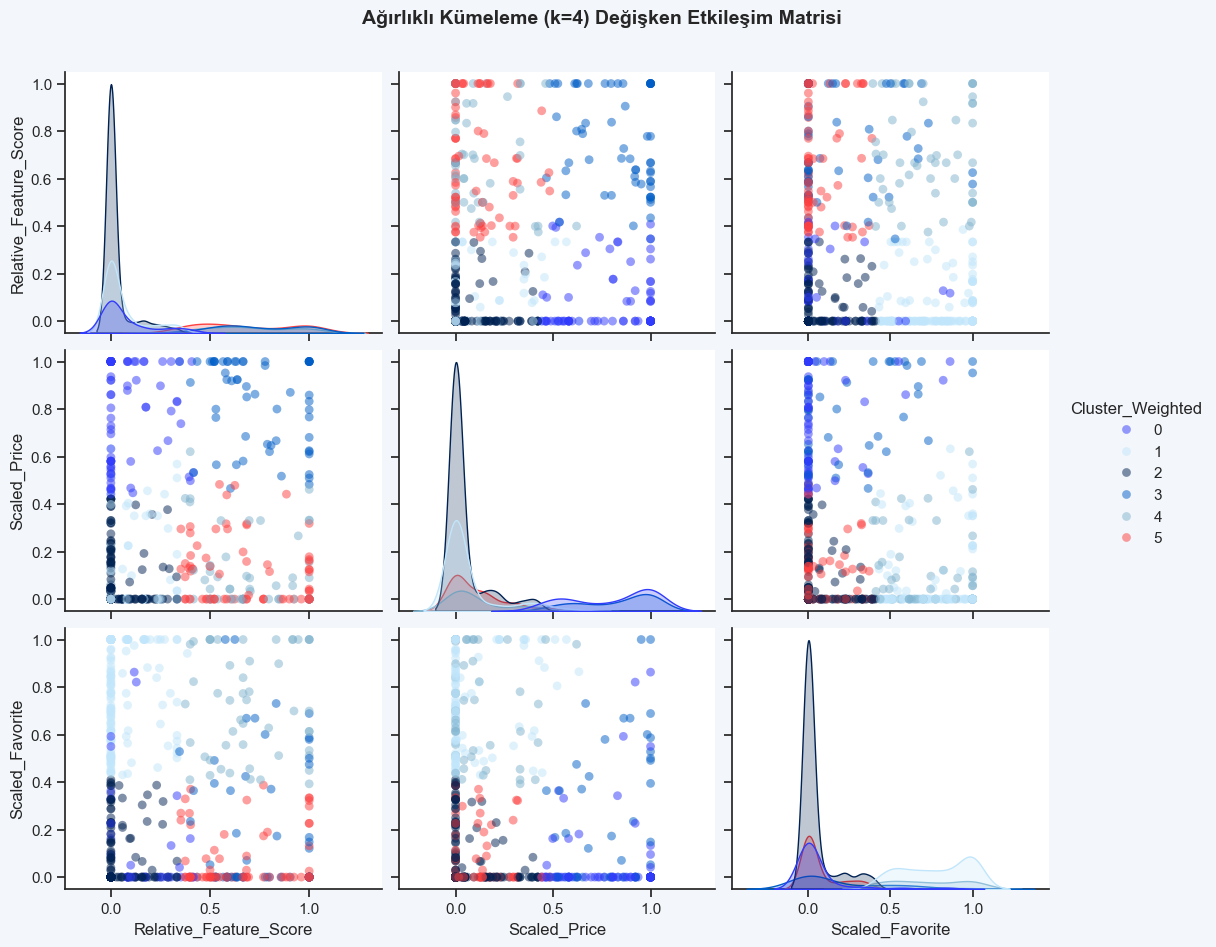

In [202]:
# 1. Renk Paleti
BEKO_PALETTE = ["#313BFB", "#C1E6FB", "#002252", "#015EC7","#81B3CE","#FD4040"]  # 6 segment için
BEKO_DARK = "#062B5F"
BEKO_GRAY = "#F3F6FA"

# 2. Stil Ayarları
sns.set_theme(style="ticks", palette=BEKO_PALETTE)

# 3. Pairplot Oluşturma
g = sns.pairplot(
    df_beko_segmentasyon, 
    vars=['Relative_Feature_Score', 'Scaled_Price', 'Scaled_Favorite'],
    hue='Cluster_Weighted', 
    palette=BEKO_PALETTE,
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 40, 'edgecolor': 'none'},
    height=3,
    aspect=1.2
)

# 4. Estetik Düzenlemeler (g.figure kullanımı deprecation uyarısını giderir)
g.figure.suptitle('Ağırlıklı Kümeleme (k=4) Değişken Etkileşim Matrisi', y=1.05, fontsize=14, fontweight='bold')
g.figure.set_facecolor(BEKO_GRAY)
plt.show()

In [203]:
fig_2d = px.scatter(
    df_beko_segmentasyon, 
    x='Relative_Feature_Score', 
    y='Scaled_Price',
    size='Scaled_Favorite', 
    color=df_beko_segmentasyon['Cluster_Weighted'].astype(str),
    hover_name='Product_Name',
    title='Ağırlıklandırılmış Segmentasyon (2D Görünüm)',
    labels={
        'Relative_Feature_Score': 'Teknoloji Skoru',
        'Scaled_Price': 'Fiyat Seviyesi (Öncelikli)'
    },
    color_discrete_sequence=BEKO_PALETTE,
    height=700,
    template='plotly_white'
)

# Kadran çizgilerini ekleyelim
fig_2d.add_hline(y=0.5, line_dash="dash", line_color="gray", opacity=0.5)
fig_2d.add_vline(x=0.5, line_dash="dash", line_color="gray", opacity=0.5)

fig_2d.update_traces(marker=dict(opacity=0.85, line=dict(width=0)))
fig_2d.update_layout(legend=dict(title='Cluster', orientation='h', y=0.98, x=0.02))

fig_2d.show()

In [218]:
# Renk Paleti
BEKO_PALETTE = ["#313BFB", "#C1E6FB", "#002252", "#015EC7","#81B3CE","#FD4040"]  # 6 segment için
BEKO_DARK = "#062B5F"
BEKO_GRAY = "#F3F6FA"

fig_3d = px.scatter_3d(
    df_beko_segmentasyon,
    x='Relative_Feature_Score',
    y='Scaled_Price',
    z='Scaled_Favorite',
    color=df_beko_segmentasyon['Cluster_Weighted'].astype(str),
    hover_name='Product_Name',
    color_discrete_sequence=BEKO_PALETTE,
    opacity=0.8,
    title='Ağırlıklandırılmış Segmentasyon (3D Uzayda Fiyat Baskınlığı)',
    labels={
        'Relative_Feature_Score': 'Teknoloji Skoru',
        'Scaled_Price': 'Fiyat Seviyesi',
        'Scaled_Favorite': 'Popülarite'
    },
    height=800
)

fig_3d.update_traces(marker=dict(size=5, opacity=0.85, line=dict(width=0)))

fig_3d.update_layout(
    scene=dict(
        xaxis_title='Teknoloji',
        yaxis_title='FİYAT (Ağırlıklı)',
        zaxis_title='Popülarite',
        xaxis=dict(backgroundcolor=BEKO_GRAY, gridcolor='white', showbackground=True),
        yaxis=dict(backgroundcolor=BEKO_GRAY, gridcolor='white', showbackground=True),
        zaxis=dict(backgroundcolor=BEKO_GRAY, gridcolor='white', showbackground=True),
        camera=dict(eye=dict(x=1.2, y=2.0, z=0.9))
    ),
    paper_bgcolor=BEKO_GRAY,
    plot_bgcolor=BEKO_GRAY,
    font=dict(color=BEKO_DARK),
    legend=dict(title='Cluster', orientation='h', y=0.98, x=0.02)
)

fig_3d.show()


k=2 için Silhouette Skoru: 0.4019
k=3 için Silhouette Skoru: 0.4488
k=4 için Silhouette Skoru: 0.5060
k=5 için Silhouette Skoru: 0.5381
k=6 için Silhouette Skoru: 0.5558
k=7 için Silhouette Skoru: 0.5290
k=8 için Silhouette Skoru: 0.5389
k=9 için Silhouette Skoru: 0.5470
k=10 için Silhouette Skoru: 0.5546


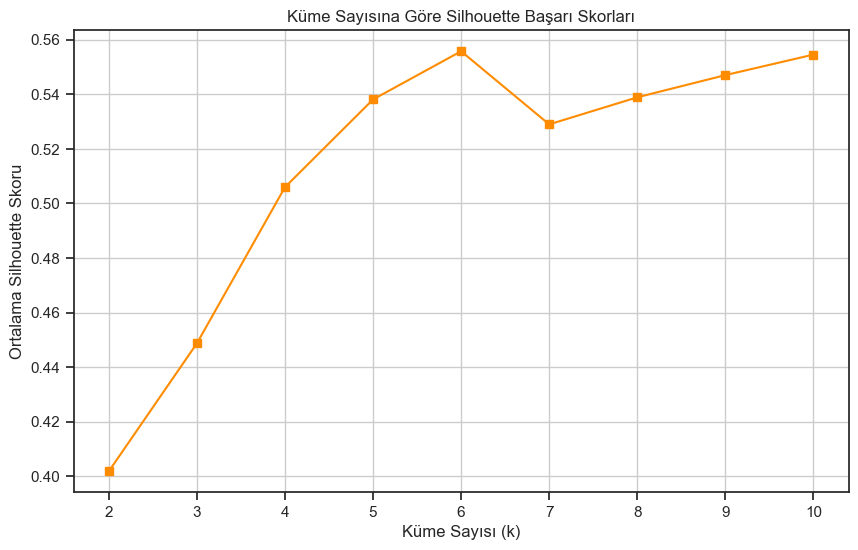

In [210]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Özellik setini belirle
X = df_beko_segmentasyon[['Relative_Feature_Score', 'Weighted_Price', 'Scaled_Favorite']]

sil_scores = []
k_range = range(2, 11) # Silhouette en az 2 küme gerektirir

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)
    
    # Her k değeri için ortalama silhouette skorunu hesapla
    score = silhouette_score(X, cluster_labels)
    sil_scores.append(score)
    print(f"k={k} için Silhouette Skoru: {score:.4f}")

# 2. Skorları Görselleştirme
plt.figure(figsize=(10, 6))
plt.plot(k_range, sil_scores, marker='s', linestyle='-', color='darkorange')
plt.title('Küme Sayısına Göre Silhouette Başarı Skorları')
plt.xlabel('Küme Sayısı (k)')
plt.ylabel('Ortalama Silhouette Skoru')
plt.grid(True)
plt.show()

In [225]:
df_beko_segmentasyon.head()

,Product_Link,Product_Name,Price,Favorite_Count,Product_Group,Main_Category,Subcategory,Holiday_Mode,ProSmart_Inverter_Compressor,Door_Direction_Change,...,Outdoor_Volume_Index_Score,Weight_kg_Score,Power_W_Score,Relative_Feature_Score,Scaled_Price,Scaled_Favorite,Weighted_Price,Cluster_Weighted,Segment_Name,Segment_Ismi
0,https://www.beko.com.tr/no-frost-buzdolabi/683616-ei-buzdolabi,683616 EI Yapay Zeka Teknolojili No Frost Buzdolabı,88409.0,104,No Frost Buzdolabi,Beyaz Eşya,Buzdolabı,1,1,1,...,0,0,0,1.000000,0.766382,0.579500,0.766382,3,Tanımlanmamış,Yeni Teknoloji / Keşfedilmemiş
1,https://www.beko.com.tr/no-frost-buzdolabi/678551-egc-ai-fit-buzdolabi,678551 EGC AI Fit No Frost Buzdolabı,71999.0,4,No Frost Buzdolabi,Beyaz Eşya,Buzdolabı,1,1,1,...,0,0,0,0.700549,0.317245,0.000000,0.317245,5,Tanımlanmamış,Fırsat / Yıldız Ürünler
2,https://www.beko.com.tr/no-frost-buzdolabi/678551-ebc-ai-fit-buzdolabi,678551 EBC AI Fit Beyaz Cam Yapay Zeka Teknolojili No Frost Buzdolabı,71999.0,7,No Frost Buzdolabi,Beyaz Eşya,Buzdolabı,1,1,1,...,0,0,0,0.777581,0.317245,0.000000,0.317245,5,Tanımlanmamış,Fırsat / Yıldız Ürünler
3,https://www.beko.com.tr/no-frost-buzdolabi/678551-esc-buzdolabi,678551 ESC Siyah Cam No Frost Buzdolabı,91889.0,41,No Frost Buzdolabi,Beyaz Eşya,Buzdolabı,1,1,1,...,0,0,0,0.664621,0.850836,0.070422,0.850836,3,Tanımlanmamış,Yeni Teknoloji / Keşfedilmemiş
4,https://www.beko.com.tr/no-frost-buzdolabi/670475-iebc-buzdolabi,670475 IEBC AI Beyaz Cam No Frost Buzdolabı,55469.0,4,No Frost Buzdolabi,Beyaz Eşya,Buzdolabı,1,0,1,...,0,0,0,0.000000,0.000000,0.000000,0.000000,2,Tanımlanmamış,Popüler Ekonomik


In [230]:
df_segmentasyon_sonuc = df_beko_segmentasyon[["Product_Link", "Product_Name", "Price", "Favorite_Count", "Product_Group", "Main_Category", "Subcategory","Relative_Feature_Score","Scaled_Price","Scaled_Favorite","Segment_Ismi"]]


Kaydedildi: ../web-scraping-data/data/claned/beko_segmentasyon_sonuc.csv


In [237]:
if 'Segment_Ismi' in df_segmentasyon_sonuc.columns:
    df_segmentasyon_sonuc['Segmentation_Name'] = df_segmentasyon_sonuc['Segment_Ismi'].replace(
        {'Yeni Teknoloji / Keşfedilmemiş': 'Premium / Lüks',
            'Fırsat / Yıldız Ürünler': 'Keşfedilmemiş Teknoloji',
            'Popüler Ekonomik': 'Düşük Segment (Giriş Seviyesi)',
            'Niş / Aşırı Fiyatlandırılmış': 'Popüler Ekonomik',
            'Düşük Segment (Giriş Seviyesi)': 'Niş / Aşırı Fiyatlandırılmış',
            'Premium / Lüks': 'Fırsat / Yıldız Ürünler'
        }
    )

display(df_segmentasyon_sonuc[['Segmentation_Name', 'Segment_Ismi']])

,Segmentation_Name,Segment_Ismi
0,Premium / Lüks,Yeni Teknoloji / Keşfedilmemiş
1,Keşfedilmemiş Teknoloji,Fırsat / Yıldız Ürünler
2,Keşfedilmemiş Teknoloji,Fırsat / Yıldız Ürünler
3,Premium / Lüks,Yeni Teknoloji / Keşfedilmemiş
4,Düşük Segment (Giriş Seviyesi),Popüler Ekonomik
5,Düşük Segment (Giriş Seviyesi),Popüler Ekonomik
6,Popüler Ekonomik,Niş / Aşırı Fiyatlandırılmış
7,Premium / Lüks,Yeni Teknoloji / Keşfedilmemiş
8,Düşük Segment (Giriş Seviyesi),Popüler Ekonomik
9,Keşfedilmemiş Teknoloji,Fırsat / Yıldız Ürünler


In [238]:
df_segmentasyon_sonuc = df_segmentasyon_sonuc.drop(columns=['Segment_Ismi'], errors='ignore')

In [239]:
save_path = r"../web-scraping-data/data/claned/beko_segmentasyon_sonuc.csv"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
df_segmentasyon_sonuc.to_csv(save_path, index=False, encoding="utf-8-sig")
print(f"Kaydedildi: {save_path}")  

Kaydedildi: ../web-scraping-data/data/claned/beko_segmentasyon_sonuc.csv
